# 03 · Price elasticity by region — random slopes & endogeneity

**The business decision.** We set prices region by region and want each region's **price elasticity of
demand** — the standard economics measure of how sensitive demand is to price. Concretely, elasticity is
the **% change in quantity sold for a 1% change in price**; it's almost always negative (raise price →
sell less). An elasticity of −1.5 means "cut price 1%, sell 1.5% more." We need it per region because a
tourist market and a price-sensitive suburb should not be priced the same.

### Two traps this notebook is built around

1. **Small regions are noisy.** A region with 12 weeks of data will hand you a wild elasticity estimate
   that's mostly sampling noise. Acting on it is overfitting. The fix is **partial pooling** (below).
2. **Price is endogenous.** "Endogenous" means the treatment (price) is *correlated with the error term*
   — here because managers historically *cut prices when they expected soft demand*. So low prices
   coincide with low demand for reasons that have nothing to do with the price cut, which drags the naive
   elasticity estimate *toward zero* (makes demand look less price-sensitive than it is). No amount of
   clever averaging fixes this — it needs an **instrument** (notebook 11). Step 0 meets it in classical
   form, before any prior appears; step 8 breaks the assumption on purpose and prices the cure.

### The tools, in plain terms

- **Log-log demand.** We model $\log(\text{quantity}) = \alpha + \beta\,\log(\text{price}) + \dots$. The
  magic of taking logs on both sides is that the slope $\beta$ **is** the elasticity directly (a constant
  %-for-% relationship), so there's one interpretable number per region. One line of calculus shows why:
  elasticity is defined as $\epsilon(P) \equiv \frac{dQ}{dP}\cdot\frac{P}{Q}$, and for the
  constant-elasticity curve $Q = A P^{\beta}$ we get
  $\epsilon(P) = \beta A P^{\beta-1}\cdot\frac{P}{A P^{\beta}} = \beta$ — the *same* $\beta$ at
  every price point. For **any other** demand shape the elasticity moves with the price level, so $\beta$
  is best read as a *local approximation around the prices we actually observed* — a point that returns
  with teeth when we recommend prices outside that range.
- **Random slopes / partial pooling.** Instead of one elasticity for all regions (ignores real
  differences) or a separate free estimate per region (noisy), we assume each region's elasticity
  $\beta_r$ is drawn from a shared distribution $\beta_r \sim \mathcal{N}(\mu_\beta, \tau_\beta^2)$. This
  **hierarchical** structure makes each region's estimate a compromise between its own noisy data and the
  fleet average — data-poor regions get pulled ("shrunk") harder toward the fleet, which is exactly the
  protection we want. $\mu_\beta$ is the typical elasticity; $\tau_\beta$ measures how much regions
  genuinely differ.

> Cookbook maps this to `pathmc` random slopes; here we fit the equivalent hierarchical model explicitly
> in PyMC so the shrinkage is fully visible. The identification logic is unchanged.

> **On real data.** Swap in your **own transaction panel** — one row per region per week with price,
> units sold, and controls (competitor price, promotions, seasonality). Public analogues are retail
> *scanner* datasets (e.g. the Dominick's Finer Foods store data). The endogeneity caveat is not academic:
> it's the single biggest reason naive "price tests" mislead in practice.

In [1]:
import os, json, warnings, logging, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import pymc as pm
logging.getLogger("pymc").setLevel(logging.CRITICAL + 1)  # SamplerWarnings log at ERROR; silence fully
from scipy import stats
from cmp import dgp, plots, estimators as est
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
FIT = dict(draws=500, tune=500, chains=2) if FAST else dict(draws=1500, tune=1500, chains=4)
SEED = 5

## 2 · Simulate a ground truth

A region × week panel with a **constant-elasticity (log-log) demand curve**
$\log Q_{rt}=\alpha_r+\beta_r\log P_{rt}+\gamma^\top Z_{rt}+\varepsilon_{rt}$, where $\beta_r$ is
region $r$'s true price elasticity (planted, varying around a fleet mean ≈ −1.4). Of the observed covariates $Z$, only **competitor price** is a genuine confounder — it moves both
our price and demand; **season** and **trend** shift demand only, so they enter as *precision
covariates* (they sharpen estimates), not confounders. We start with **no** endogeneity so we
can show recovery, then switch it on in step 8.

**The data-generating model** — exactly what `dgp.price_panel` implements (defaults & seed in
`src/cmp/dgp.py`). For region $r$, week $t$: season $s_t = 0.3\sin(2\pi t/26)$, trend
$g_t = 0.01\,t$, competitor price $C_{rt} \sim \mathcal N(20,\, 2^{2})$, and a demand shock
$u_{rt} \sim \mathcal N(0,1)$:

$$
\begin{aligned}
\beta_r &\sim \mathcal N(-1.4,\; 0.35^{2})\\[2pt]
\log P_{rt} &= \log 15 \;-\; 0.05\, C_{rt}/20 \;+\; \kappa\, u_{rt} \;+\; \nu_{rt},
  \qquad \nu_{rt} \sim \mathcal N(0,\, 0.05^{2})\\[2pt]
\log Q_{rt} &= 2.5 \;+\; \beta_r \log P_{rt} \;+\; 0.4\,\tfrac{C_{rt}-20}{20} \;+\; s_t \;+\; g_t
  \;+\; u_{rt} \;+\; \varepsilon_{rt}, \qquad \varepsilon_{rt} \sim \mathcal N(0,\, 0.08^{2}).
\end{aligned}
$$

Line 1 plants the true regional elasticities; line 2 is the price-setting rule; line 3 is
demand. $C_{rt}$ appears in **both** equations — that is what makes competitor price the genuine confounder
(it moves our price *and* demand), while $s_t$ and $g_t$ appear only in the demand equation
(precision covariates). $\kappa$ is the **endogeneity switch**: through step 6 the generator runs with $\kappa = 0$
and zeroes the shock entirely ($u_{rt} \equiv 0$), so recovery is clean; step 8 sets
$\kappa > 0$, and the *same* shock now enters both equations — managers' prices respond to the
very shock that moves demand ($\text{Cov}(\log P, u) > 0$), the simultaneity that biases the
naive elasticity toward zero.


In [2]:
df, true_elast = dgp.price_panel(n_regions=12, n_weeks=80, confounder_strength=0.0, seed=SEED)
df["log_price"] = np.log(df["price"]); df["log_demand"] = np.log(df["demand"])
regions = sorted(df["region"].unique()); R = len(regions)
r_idx = df["region"].map({r: i for i, r in enumerate(regions)}).values
# deliberately thin out a few regions so shrinkage has something to do
keep = np.ones(len(df), bool)
for i in [0, 1, 2]:
    ridx = np.where(r_idx == i)[0]
    drop = np.random.default_rng(i).choice(ridx, size=int(len(ridx) * 0.8), replace=False)
    keep[drop] = False
df, r_idx = df[keep].reset_index(drop=True), r_idx[keep]
counts = pd.Series(r_idx).value_counts().sort_index()
print(f"{R} regions, fleet-mean elasticity {true_elast.mean():.2f}; obs per region range {counts.min()}–{counts.max()} "
      f"(regions 0-2 are thin, to exercise shrinkage)")
df.head()

12 regions, fleet-mean elasticity -1.42; obs per region range 16–80 (regions 0-2 are thin, to exercise shrinkage)


,region,week,price,demand,competitor_price,season,trend,log_price,log_demand
0,region_00,2,13.003239,0.159630,20.405765,1.394170e-01,0.02,2.565199,-1.834900
1,region_00,3,14.245949,0.157405,16.535730,1.989368e-01,0.03,2.656473,-1.848934
2,region_00,12,14.310937,0.159097,20.819276,7.179470e-02,0.12,2.661024,-1.838239
3,region_00,13,15.626376,0.175255,21.659711,-9.648736e-17,0.13,2.748960,-1.741513
4,region_00,15,13.204126,0.152195,19.486540,-1.394170e-01,0.15,2.580529,-1.882592


## 3 · Identify — what must be true for $\beta_r$ to be causal?

**Identification vs estimation.** *Identification* asks whether the causal quantity could be recovered
from this data even with infinite samples — a question about **assumptions**, settled before any fitting;
*estimation* is the statistics we do once identification is granted. Partial pooling (below) is an
**estimation** device — it buys variance reduction, never identification.

**Estimand.** Region $r$'s elasticity is a *causal* slope — what happens to demand when **we** move the
price, not when the market moves it for us:

$$
\beta_r \;=\; \frac{\partial\, \mathbb{E}\big[\log Q \,\big|\, \mathrm{do}(\log P = p),\, r\big]}{\partial p},
$$

where $\mathrm{do}(\cdot)$ marks an *intervention* on price (Pearl's do-operator), as opposed to passively
observing whatever prices managers happened to choose. The regression slope equals this causal slope only
under assumptions — four of them, each named, formalized, and honestly labelled as checkable or not:

**A1 · Conditional price exogeneity** (the continuous-treatment version of **unconfoundedness** — once we hold the observed controls fixed, price is as-good-as-randomly assigned with respect to the demand shock):

$$
\varepsilon_{rt} \;\perp\; \log P_{rt} \;\big|\; Z_{rt},\, r .
$$

After conditioning on region and the observed controls $Z$, whatever noise remains in demand must be
unrelated to how the price was set. The one true observable confounder in our DGP is **competitor price**
— it moves both $P$ and $Q$, opening a **backdoor path** in the DAG below — a *backdoor path* is a non-causal route linking price and demand through a common cause (here $P \leftarrow$ competitor price $\rightarrow Q$) that manufactures correlation which is *not* the price effect — and conditioning on it closes
that path. **Season** and **trend** move demand only, so they are *precision covariates* (they sharpen
estimates), not confounders. A1 holds by construction while $\kappa=0$; it is *exactly* the assumption we
break in step 8, and it is **untestable from the data alone** — no diagnostic in this notebook can
certify it.

**A2 · Price variation — genuine price movement left after the controls** (the continuous-treatment form of **positivity**):

$$
\mathrm{Var}(\log P_{rt} \mid Z_{rt},\, r) \;>\; 0 .
$$

Each region must have genuine price movement left over after the controls; no variation, no slope. In the
DGP this is the quasi-experimental wiggle $\nu_{rt}\sim\mathcal N(0,\,0.05^2)$ — checked numerically in
the next cell. In real data this is the assumption most often *silently* violated: uniform corporate
pricing or rigid cost-plus rules leave $\mathrm{Var}(\log P \mid Z)\approx 0$, and the "elasticity" you
then estimate is noise dressed up as a number.

**A3 · No dynamic effects / SUTVA** (Stable Unit Treatment Value Assumption)**.** This week's price affects this week's demand only: no stockpiling
("pantry-loading" ahead of a price rise), no delayed reference-price effects, and no cross-region
spillovers (region A's price doesn't move region B's demand — no arbitrage). Our DGP satisfies this by
construction; on real scanner data a `lag(price)` term is the standard first probe (step 8's caveats).

**A4 · Functional form.** In a *parametric* model the constant-elasticity (log-log) shape is part of the
identification bundle: if the true curve bends, the "constant" $\beta_r$ is a price-range-specific
average. We stress-test this in-sample in step 5 with a curvature term — but no in-sample check reaches
prices we never charged.

**Partial pooling, and what it buys.** The estimand is per-region, so we treat elasticity as a **random
slope**: $\beta_r\sim\mathcal N(\mu_\beta,\tau_\beta^2)$ — noisy regions shrink toward the fleet
mean $\mu_\beta$, and $\tau_\beta$ (a standard deviation — the between-region spread of elasticities) *measures how much elasticity genuinely varies*. The
**shrinkage factor** for region $r$ is approximately
$\;1-\dfrac{\tau_\beta^2}{\tau_\beta^2+\sigma^2/n_r}\;$ — thin regions (small $n_r$) get pulled
harder toward the fleet. Shrinkage is a feature: it stops us over-reacting to a small region's
noisy slope. But pooling handles *noise*, not *bias*: if A1 fails, all three pooling regimes in step 4
are biased by the same amount.

**How big is the bias if A1 fails? Two lines of algebra, not hand-waving.** Suppose an unobserved shock
$u_{rt}$ (variance $\sigma_u^2$) enters demand with coefficient 1 *and* leaks into price with coefficient
$\kappa$ (managers cut price when they expect soft demand). For the regression of $\log Q$ on $\log P$
after partialling out $Z$ and region effects (i.e. after regressing price and demand on the controls and keeping only the residual variation), the classic **omitted-variable-bias** formula gives

$$
\hat\beta \;\xrightarrow{\;p\;}\; \beta \;+\; \frac{\mathrm{Cov}(\log P,\, u)}{\mathrm{Var}(\log P)}
\;=\; \beta \;+\; \frac{\kappa\,\sigma_u^2}{\kappa^2\sigma_u^2 + \sigma_\nu^2},
$$

using the DGP's price equation ($\mathrm{Cov}(\log P, u)=\kappa\sigma_u^2$ and
$\mathrm{Var}(\log P \mid Z)=\kappa^2\sigma_u^2+\sigma_\nu^2$). The arrow $\xrightarrow{p}$ reads "converges in probability to" — the value the estimate settles on as the sample grows. The bias term is **positive**, and since
$\beta<0$ it drags $\hat\beta$ **toward zero** — demand looks less price-sensitive than it is. Worse, the
*sign of the whole slope can flip*: when the exogenous wiggle $\sigma_\nu$ is small, even a faint
$\kappa$ makes the bias enormous (the denominator is tiny) and the fitted "demand curve" slopes *upward*
— high prices coinciding with high demand because both chase the same shock. Step 8 verifies this
arithmetic numerically, then sweeps $\kappa$ to map the whole curve. What pooling does **not** fix is
exactly this: an *unobserved* common shock needs an instrument — previewed in step 8, full treatment in
notebook 11. We state this out loud rather than hide it.

A2 check — within-region SD of log-price: min 0.046, median 0.052, max 0.058 (all comfortably > 0: positivity holds, by design)


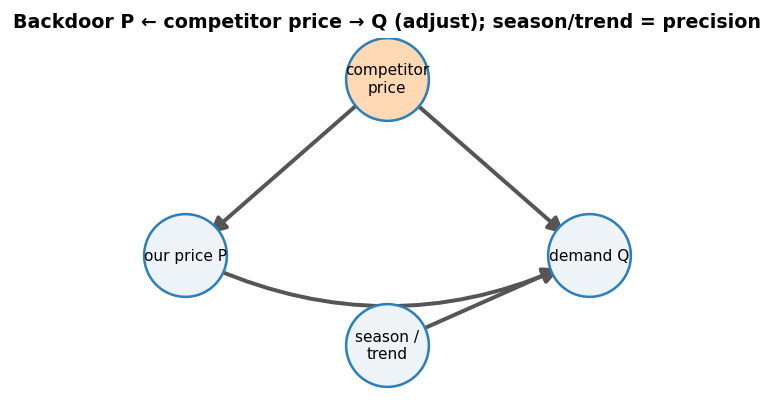

In [3]:
# The DAG behind the estimand. Competitor price is the confounder — it moves BOTH our price
# and demand, opening the backdoor P <- competitor -> Q we must adjust for. Season/trend push
# demand only (precision covariates). The causal arrow of interest is P -> Q (elasticity beta).
fig, axd = plt.subplots(figsize=(5.6, 3.2))
plots.draw_dag(
    axd,
    pos={"competitor\nprice": (0.5, 1.0), "our price P": (0.12, 0.35),
         "demand Q": (0.88, 0.35), "season /\ntrend": (0.5, 0.02)},
    edges=[("competitor\nprice", "our price P"), ("competitor\nprice", "demand Q"),
           ("our price P", "demand Q"), ("season /\ntrend", "demand Q")],
    node_colors={"competitor\nprice": "#ffd9b3"},
    curved={("our price P", "demand Q")},
    title="Backdoor P \u2190 competitor price \u2192 Q (adjust); season/trend = precision")
fig.tight_layout()

# A2 positivity check: genuine within-region price variation (the DGP plants nu ~ N(0, 0.05^2) of
# quasi-experimental wiggle on top of the competitor-price passthrough). Were these ~0, no elasticity
# could be identified in that region no matter how clever the model.
lp_sd = df.groupby("region")["log_price"].std()
print(f"A2 check — within-region SD of log-price: min {lp_sd.min():.3f}, median {lp_sd.median():.3f}, "
      f"max {lp_sd.max():.3f} (all comfortably > 0: positivity holds, by design)")

## Step 0 · The classical read (no likelihood, no priors, no sampler)

Before any Bayesian machinery, ask what a competent analyst does here **without** it. The answer is not a
different analysis: it is the *same estimand* (§3's causal slope), identified by the *same four
assumptions* (A1–A4), estimated with the simplest tool that is still correct. And in a log-log demand
curve that tool is almost embarrassingly simple, because **the estimand is a regression coefficient**:

$$\log Q_{rt} \;=\; \alpha_r \;+\; \beta\,\log P_{rt} \;+\; \gamma^\top Z_{rt} \;+\; \varepsilon_{rt},$$

with region intercepts $\alpha_r$ (twelve dummies) and $Z$ the §3 adjustment set (competitor price,
season, trend). The coefficient on $\log P$ **is** the elasticity — no back-transformation, no marginal
effect to compute, no delta method. One `cl.ols` call returns it, and it is the number the whole notebook
is about.

**What the classical arm cannot do — and this is the crux.** The estimand is per-region, and OLS has
exactly **two** ways to deliver a per-region elasticity: pretend the regions are identical (**complete
pooling** — the single $\beta$ above, one number quoted twelve times) or estimate each region from its own
weeks alone (**no pooling** — twelve separate regressions, three of them on 16 observations). There is no
third option in the classical toolbox. Hold that thought: §4's hierarchical model is the third option, and
**5x** settles the account between them.

**The covariance choice is not a detail — it is the estimate's other half.** Our region-weeks are not
independent observations, and for two reasons, of which only the second is the textbook one:

1. **The pooled model is deliberately wrong about slopes.** §2 planted $\beta_r\sim\mathcal
   N(-1.4,\,0.35^2)$ — regions genuinely differ. Force one shared $\beta$ on them and each region's
   residual inherits a term $(\beta_r-\beta)\log P_{rt}$ that is *the same sign, week after week, for that
   region*. That is within-region correlation manufactured by the specification itself.
2. **Real panels add serially-correlated local shocks** on top (a soft month tends to be followed by
   another soft month).

Neither is visible to the iid or HC1 formulas, which only ever look at one row at a time. **Clustering on
region** lets the errors be arbitrarily correlated *within* a region and asks only for independence
*across* regions, so the **12 regions**, not the 768 rows, become the unit of inference — the correction
of **Bertrand–Duflo–Mullainathan (2004)**, whose famous finding is that ignoring within-panel correlation
can leave standard errors off by a factor of five or more. So we fit the same regression **three times** —
iid, HC1, region-clustered — and print all three. The point estimate will be identical to the last
decimal; only the story about its precision changes.

**One caveat to hear *before* the number appears.** We have **12** clusters. Cluster-robust standard
errors are a large-$G$ approximation; at $G=12$ they are themselves *downward*-biased (the usual rule of
thumb wants 30–50 clusters, and with fewer you are supposed to reach for a wild cluster bootstrap). So the
clustered interval below is the best interval the classical toolbox has here — and it is still, mildly, an
optimistic one. No covariance option fixes that. The honest fix is to *model* the region-level variation,
which is exactly what §4 will do.

**The confounding story, priced.** §3 claimed competitor price is the one genuine confounder and that
season/trend are mere *precision covariates*. We test that claim by dropping controls one block at a time.
And because a single sample cannot tell **bias** from **bad luck**, we then repeat the whole exercise on
fresh panels and report the *average* error across seeds — the only way to see which omissions move the
estimate systematically and which merely make it wobble.

In [4]:
from cmp import classical as cl

# The standardized controls as patsy columns — the SAME Z the Bayesian model will use in section 4.
_zs = df[["competitor_price", "season", "trend"]].values
_zs = (_zs - _zs.mean(0)) / _zs.std(0)
df["z_comp"], df["z_season"], df["z_trend"] = _zs[:, 0], _zs[:, 1], _zs[:, 2]
F_FULL = "log_demand ~ log_price + z_comp + z_season + z_trend + C(region)"

# THE ESTIMAND: the coefficient on log_price. Same fit, three covariance assumptions.
fleet_cl = cl.ols(df, F_FULL, target="log_price", cov="cluster", cluster="region",
                  name="Fleet elasticity (pooled log-log OLS)")
fleet_hc = cl.ols(df, F_FULL, target="log_price", cov="HC1")
fleet_id = cl.ols(df, F_FULL, target="log_price", cov="nonrobust")

def row(lab, r, w=19):                              # one compact line per fit
    return (f"  {lab:<{w}s}{r.estimate:>6.2f}  [90% CI {r.ci[0]:+.2f}, {r.ci[1]:+.2f}]"
            f"  SE {r.se:.3f}")
print("THE ESTIMAND — the fleet price elasticity: the log-price coefficient of the")
print(f"pooled log-log fit ({fleet_cl.n:,} region-weeks, {fleet_cl.extra['n_clusters']} regions).")
print("One point estimate; three stories about how precise it is:")
print(row("iid (nonrobust)", fleet_id))
print(row("HC1 (robust)", fleet_hc))
print(row("clustered on region", fleet_cl))
print(f"  -> clustering on region multiplies the SE by x{fleet_cl.se / fleet_hc.se:.2f} vs HC1 "
      f"(x{fleet_cl.se / fleet_id.se:.2f} vs iid).")

true_fleet = float(true_elast.mean())
inside = fleet_cl.ci[0] <= true_fleet <= fleet_cl.ci[1]
print(f"\nGRADE vs the planted truth (fleet-mean beta = {true_fleet:.2f}): the pooled")
print(f"  estimate is off by {fleet_cl.estimate - true_fleet:+.2f}, and the truth falls "
      f"{'INSIDE' if inside else 'OUTSIDE'} the clustered 90% CI.")
print(f"  The classical estimator lands the FLEET number; what it cannot land is")
print(f"  the twelve regional ones (5x).")

# --- The control ladder: which omission is bias, and which is only noise? ---
LADDER = [("all controls (section 3's)", F_FULL),
          ("drop COMPETITOR PRICE", "log_demand ~ log_price + z_season + z_trend + C(region)"),
          ("drop SEASON + TREND", "log_demand ~ log_price + z_comp + C(region)"),
          ("drop everything (bivariate)", "log_demand ~ log_price")]
print("\nTHE CONTROL LADDER — competitor price is the confounder, season/trend are the")
print("precision covariates (region-clustered SEs throughout):")
for lab, f_ in LADDER:
    print(row(lab, cl.ols(df, f_, target="log_price", cov="cluster", cluster="region"), w=28))

# One sample cannot separate bias from luck. Re-run the ladder on fresh panels and average the ERROR.
NSEED = 8 if FAST else 25
errs = {k: [] for k in ("full", "no competitor", "no season/trend")}
ses = {k: [] for k in ("full", "no season/trend")}
for s_ in range(NSEED):
    d_, te_ = dgp.price_panel(n_regions=12, n_weeks=80, confounder_strength=0.0, seed=1000 + s_)
    d_["log_price"], d_["log_demand"] = np.log(d_["price"]), np.log(d_["demand"])
    zz = d_[["competitor_price", "season", "trend"]].values; zz = (zz - zz.mean(0)) / zz.std(0)
    d_["z_comp"], d_["z_season"], d_["z_trend"] = zz[:, 0], zz[:, 1], zz[:, 2]
    for key, f_ in (("full", F_FULL), ("no competitor", LADDER[1][1]), ("no season/trend", LADDER[2][1])):
        r_ = cl.ols(d_, f_, target="log_price", cov="HC1")
        errs[key].append(r_.estimate - te_.mean())
        if key in ses:
            ses[key].append(r_.se)
print(f"\nBIAS vs NOISE — the same ladder over {NSEED} fresh panels")
print(f"(mean error against each panel's own planted truth):")
for k, v in errs.items():
    v = np.array(v)
    print(f"  {k:<16s} mean error {v.mean():+.3f}   (seed-to-seed sd {v.std():.3f})")
print(f"  typical SE: full {np.mean(ses['full']):.3f}  vs  no season/trend {np.mean(ses['no season/trend']):.3f} "
      f"(x{np.mean(ses['no season/trend']) / np.mean(ses['full']):.1f} wider)")

THE ESTIMAND — the fleet price elasticity: the log-price coefficient of the
pooled log-log fit (768 region-weeks, 12 regions).
One point estimate; three stories about how precise it is:
  iid (nonrobust)     -1.39  [90% CI -1.49, -1.30]  SE 0.058
  HC1 (robust)        -1.39  [90% CI -1.49, -1.29]  SE 0.061
  clustered on region -1.39  [90% CI -1.54, -1.24]  SE 0.091
  -> clustering on region multiplies the SE by x1.50 vs HC1 (x1.58 vs iid).

GRADE vs the planted truth (fleet-mean beta = -1.42): the pooled
  estimate is off by +0.03, and the truth falls INSIDE the clustered 90% CI.
  The classical estimator lands the FLEET number; what it cannot land is
  the twelve regional ones (5x).

THE CONTROL LADDER — competitor price is the confounder, season/trend are the
precision covariates (region-clustered SEs throughout):
  all controls (section 3's)   -1.39  [90% CI -1.54, -1.24]  SE 0.091
  drop COMPETITOR PRICE        -1.44  [90% CI -1.60, -1.27]  SE 0.102
  drop SEASON + TREND          


BIAS vs NOISE — the same ladder over 25 fresh panels
(mean error against each panel's own planted truth):
  full             mean error +0.016   (seed-to-seed sd 0.043)
  no competitor    mean error -0.062   (seed-to-seed sd 0.040)
  no season/trend  mean error +0.043   (seed-to-seed sd 0.175)
  typical SE: full 0.054  vs  no season/trend 0.186 (x3.4 wider)


**Read the three covariance rows, then the ladder.**

**The covariance.** Clustering on region *widened* the interval — the ratio is printed above. That is the
direction people expect, but not for the reason they expect: our DGP's weekly shocks are iid by
construction, so there is no serial correlation for the cluster-robust sandwich to find. What it finds is
the *first* mechanism listed above — the pooled model's own misspecification. Each region's residuals
carry that region's slope deviation $(\beta_r-\beta)\log P_{rt}$, week after week, and HC1 (which
inspects one row at a time) cannot see it, so it reports a precision the pooled model does not have.
Clustering looks at the twelve regional trajectories, sees the structure, and charges for it. **The iid
and HC1 intervals are not conservative or anti-conservative as a rule — they are simply wrong in a
direction you cannot predict without doing the clustering.** And note the tell: the widening is itself
evidence that the pooled specification is misspecified. The classical machinery is *telling us* that one
$\beta$ is not enough — it just has no way to act on the message.

**The ladder.** Two omissions, two entirely different failures, and only the seed loop can tell them
apart:

- Dropping **competitor price** — the real confounder, the one with the backdoor path in the DAG — moves
  the estimate by a *small but systematic* amount: across fresh panels the mean error is clearly non-zero
  (printed above), and it points **away from zero** (demand looks *more* price-sensitive than it is). The sign
  is exactly what the DGP dictates: a competitor price rise *lifts* our demand ($+0.4$) while *lowering*
  our own price ($-0.05\,C/20$), so an analyst who ignores it sees cheap weeks coinciding with strong
  weeks and credits the price cut for demand the competitor delivered. That is textbook omitted-variable
  bias, and unlike noise it does **not** shrink with more data. It is small here only because that
  passthrough is weak by construction; with a strong one the same mechanism is ruinous. (Note it is a
  *different* bias from §3's toward-zero formula, which concerns the **unobserved** shock $u$ — that one
  arrives in §8, and it is an order of magnitude worse.)
- Dropping **season and trend** — the "precision covariates", which the DAG says are *not* confounders —
  leaves the mean error near zero across seeds (no bias, exactly as advertised) but **multiplies the
  standard error several-fold** and inflates the seed-to-seed scatter to match. On *this* particular
  panel it happened to throw the point estimate a long way (see the ladder print) — and that is *noise*,
  not bias, which is precisely what a single sample can never tell you and the seed loop can.

The practical lesson generalizes past this notebook: when the treatment barely moves — here $\log P$ has
a standard deviation of about 0.05 — anything that explains a large share of the *outcome* is worth
controlling for even when it is not a confounder, because the residual variance it removes is what the
slope is estimated from. "Precision covariate" sounds optional. It is not.

---

### The assumption that will break — and the classical cure, met now

A1 (conditional price exogeneity) is the load-bearing assumption, and §8 breaks it on purpose: managers
cut prices *because* they expect soft demand, so an **unobserved** shock $u_{rt}$ sits in the price
equation and in the demand equation at once. No standard error fixes that, no amount of pooling fixes
that, and — the point worth internalizing — **no diagnostic in §5 will even notice**. The classical world
has a cure, and the reader should meet it *before* meeting any prior, because it is not a Bayesian idea at
all.

The cure is an **instrument** $W$: a variable that moves **price** but has **no path to demand except
through price**. The textbook pricing instrument is a **cost shifter** — a wholesale-cost or exchange-rate
shock moves what we charge, but shoppers never see it except in the price tag. Three conditions, and only
the first is checkable:

- **Relevance:** $\mathrm{Cov}(W,\log P)\neq 0$ — measured by the **first-stage $F$**, i.e. how hard the
  instrument moves price once the controls are partialled out (Stock–Yogo rule of thumb: $F<10$ means the
  instrument is too weak to use, and a weak instrument is *worse* than none — it drags 2SLS back toward
  OLS while inflating its interval).
- **Exclusion:** $W$ affects $\log Q$ *only through* $\log P$ — untestable, argued from institutions
  (customers do not observe our wholesale costs).
- **Independence:** $W \perp u$ — cost shocks do not chase demand shocks.

**Two-stage least squares (2SLS)** then throws away every scrap of price variation except the clean,
$W$-driven slice:

$$
\text{stage 1: } \widehat{\log P} \;=\; \hat\pi_0 + \hat\pi_1 W + \hat\pi_Z^\top Z, \qquad
\text{stage 2: } \log Q \;=\; \alpha + \beta_{\mathrm{IV}}\, \widehat{\log P} + \gamma^\top Z + e .
$$

The endogenous slice of price ($\kappa u$) is orthogonal to $W$, so stage 1 filters it out and
$\beta_{\mathrm{IV}}$ recovers the causal slope. `dgp.price_panel` has no instrument built in, so we plant
one on the $\kappa=1.2$ panel by hand: a cost shock $W_{rt}\sim\mathcal N(0,1)$ that shifts log-price by
$0.25\,W_{rt}$ and shifts log-demand **only through that price move** (by $\beta_r\times$ the price
shift) — exclusion true by construction. `cl.iv_2sls` does the algebra, with the *proper* 2SLS standard
errors (not the naive second-stage OLS output, which ignores that stage 1 was itself estimated) and the
first-stage $F$. This panel and these two fits are built **once, here**, and §8 reuses them.

In [5]:
# The endogenous panel (kappa = 1.2) that section 8 will refit hierarchically -- built ONCE, here.
df2, true2 = dgp.price_panel(n_regions=12, n_weeks=80, confounder_strength=1.2, seed=SEED)
lp2, ld2 = np.log(df2["price"].values), np.log(df2["demand"].values)
r2 = df2["region"].map({r: i for i, r in enumerate(regions)}).values
z2 = df2[["competitor_price", "season", "trend"]].values; z2 = (z2 - z2.mean(0)) / z2.std(0)

# ...plus a planted cost-shifter instrument W: it moves price, and moves demand ONLY through price.
W = np.random.default_rng(SEED + 100).normal(size=len(lp2))
shift = 0.25 * W                                   # cost passthrough into log-price (stage-1 relevance)
lp_iv = lp2 + shift                                # price moves with the cost shock...
ld_iv = ld2 + true2[r2] * shift                    # ...demand responds ONLY through price: exclusion by construction

iv_df = pd.DataFrame({"log_demand": ld_iv, "log_price": lp_iv, "W": W, "region": df2["region"].values,
                      "z_comp": z2[:, 0], "z_season": z2[:, 1], "z_trend": z2[:, 2]})
_D = pd.get_dummies(iv_df["region"], prefix="reg", drop_first=True).astype(float)   # region intercepts
iv_df = pd.concat([iv_df, _D], axis=1)
CTRL = ["z_comp", "z_season", "z_trend"] + list(_D.columns)

# (a) the competent NAIVE fit: same controls, same clustering, endogenous price. (b) the IV fit.
ols_endog = cl.ols(iv_df, "log_demand ~ log_price + " + " + ".join(CTRL), target="log_price",
                   cov="cluster", cluster="region", name="Fleet elasticity (OLS, endogenous price)")
ols_endog_hc = cl.ols(iv_df, "log_demand ~ log_price + " + " + ".join(CTRL), target="log_price", cov="HC1")
iv = cl.iv_2sls(iv_df, outcome="log_demand", endog="log_price", instrument="W", controls=CTRL)

beta_ols, se_ols = ols_endog.estimate, ols_endog.se       # names reused by the figure in section 8
beta_iv, se_iv = iv.estimate, iv.se
F1 = float(iv.extra["first_stage_F"])
true_fleet2 = float(true2.mean())

print(f"A1 BROKEN (kappa = 1.2). Truth is unchanged: fleet-mean beta = {true_fleet2:.2f}.\n")
for lab, r_ in (("OLS (endogenous)", ols_endog), ("2SLS (instrumented)", iv)):
    print(f"  {lab:<21s}{r_.estimate:>6.2f}  [90% CI {r_.ci[0]:+.2f}, {r_.ci[1]:+.2f}]  SE {r_.se:.3f}")
print(f"  first-stage F = {F1:.0f} "
      f"({'>10: relevant, not weak' if not iv.extra['weak'] else '<10: WEAK — do not use'})")
for nm, r_ in (("OLS ", ols_endog), ("2SLS", iv)):
    d_ = abs(r_.estimate - true_fleet2) / r_.se
    cov_ = r_.ci[0] <= true_fleet2 <= r_.ci[1]
    print(f"  -> {nm}: {d_:.1f} SEs from the truth; the truth is {'INSIDE' if cov_ else 'OUTSIDE'} its 90% CI.")
print(f"\n  OLS is PRECISELY WRONG — and its most 'efficient' standard error is the")
print(f"  most confident lie of all: under HC1 the same estimate carries SE "
      f"{ols_endog_hc.se:.2f} (vs {ols_endog.se:.2f}")
print(f"  clustered), putting the truth "
      f"{abs(ols_endog.estimate - true_fleet2) / ols_endog_hc.se:.0f} SEs away.")
print(f"  2SLS is IMPRECISELY RIGHT — its interval is "
      f"x{(iv.ci[1]-iv.ci[0])/(ols_endog.ci[1]-ols_endog.ci[0]):.1f} wider, and it covers.")
print(f"  (cl.iv_2sls reports homoskedastic 2SLS SEs; clustering them would widen it")
print(f"  further, so even this is the optimistic version of the IV bargain.)")
print(f"\n  THE DECISION, not the decimal: section 7's pricing rule acts only where")
print(f"  beta < -1. The OLS estimate ({ols_endog.estimate:+.2f}) sits on the "
      f"{'INELASTIC' if ols_endog.estimate > -1 else 'elastic'} side of that line,")
print(f"  with a tight interval — so a competent classical analyst handed an endogenous")
print(f"  panel would confidently HOLD PRICES FLEET-WIDE. 2SLS ({iv.estimate:+.2f}) puts them back")
print(f"  on the elastic side. Endogeneity does not shade the number; it reverses the call.")
print("\n" + fleet_cl.cannot_say())

A1 BROKEN (kappa = 1.2). Truth is unchanged: fleet-mean beta = -1.42.

  OLS (endogenous)      -0.63  [90% CI -0.78, -0.48]  SE 0.092
  2SLS (instrumented)   -1.66  [90% CI -2.01, -1.31]  SE 0.212
  first-stage F = 27 (>10: relevant, not weak)
  -> OLS : 8.6 SEs from the truth; the truth is OUTSIDE its 90% CI.
  -> 2SLS: 1.1 SEs from the truth; the truth is INSIDE its 90% CI.

  OLS is PRECISELY WRONG — and its most 'efficient' standard error is the
  most confident lie of all: under HC1 the same estimate carries SE 0.02 (vs 0.09
  clustered), putting the truth 45 SEs away.
  2SLS is IMPRECISELY RIGHT — its interval is x2.3 wider, and it covers.
  (cl.iv_2sls reports homoskedastic 2SLS SEs; clustering them would widen it
  further, so even this is the optimistic version of the IV bargain.)

  THE DECISION, not the decimal: section 7's pricing rule acts only where
  beta < -1. The OLS estimate (-0.63) sits on the INELASTIC side of that line,
  with a tight interval — so a competent clas

**Read-out — the classical answer, in business terms.** On the clean panel (A1 holding), a pooled log-log
regression with region intercepts and the §3 controls says fleet demand is **elastic**: a 1% price cut
buys appreciably more than 1% of extra volume (the number is printed above), the planted truth sits inside
the region-clustered 90% interval, and the
whole interval lies below $-1$ — so at the *fleet* level, the classical arm alone is enough to say "we are
leaving money on the table with a single national price." On the endogenous panel, the same competent
analyst — same controls, same clustering, no mistakes — is handed an elasticity on the **wrong side of the
decision line** with a tight interval around it, and 2SLS with a cost-shifter instrument ($F$ printed
above, comfortably past the Stock–Yogo bar) hands the causal slope back at the cost of a much wider
interval. That asymmetry is the whole IV bargain, and §8 will price it properly.

Notice what has **not** happened yet. No likelihood was written down, no prior was chosen, no sampler ran.
The causal work was done by the *identification* — A1–A4, and an instrument when A1 fails — not by the
machinery. **This is the honest baseline against which the Bayesian section must justify itself**, and 5x
will hold it to that. Notice, too, exactly where the classical arm ran out of road: it gave us **one**
elasticity, and the business needs **twelve**.

**The guardrail — what that confidence interval does *not* say** (printed above, and printed in the same
words in every notebook of this cookbook): it is **not** a 90% probability that the true elasticity lies
inside it. A confidence interval is a property of the *procedure* — 90% of intervals built this way would
cover the truth across repeated samples — and this particular interval either covers it or it does not.
Here is exactly where that bites, and it is not pedantry. §7's pricing rule is

$$\text{set the optimal price in region } r \iff \mathbb P\big(\beta_r < -1\big) \;\ge\; 0.9 ,$$

a probability **about the elasticity itself**, evaluated region by region. The classical apparatus can
report "region $r$'s **one-sided 90%** confidence bound clears $-1$" — and 5x scores it on exactly that,
at exactly this 0.9, so the two arms meet at the same bar. But *matching the level is not emitting the
number*. That bound is a statement about the **procedure** — 90% of bounds built this way sit on the right
side of the truth in repeated sampling — and it is emphatically **not** a 0.9 probability that region $r$
is elastic. There is nothing to plug into a rule of the form "act when the probability exceeds $x$", and
nothing to hand a CMO who asks *"how sure are we about region 5, specifically?"* That quantity does not
exist in the frequentist vocabulary; it exists in a posterior. That, and not a better point estimate, is
what §4 is for — and 5x will grade whether it delivers.

## 4 · Estimate — three pooling regimes, side by side

To make the bias–variance trade-off concrete we estimate each region's elasticity **three ways**:

- **No pooling** — a separate regression per region. Unbiased, but a data-poor region's estimate is pure
  noise. This is the "trust each region's own numbers" extreme.
- **Complete pooling** — one elasticity for the whole fleet. Rock-steady, but pretends every region is
  identical, so it's biased for any region that genuinely differs. The "everyone's the same" extreme.
- **Partial pooling** — the hierarchical Bayesian middle ground: each $\beta_r$ is nudged toward the fleet
  mean by an amount that depends on how much data the region has. Data-rich regions barely move; data-poor
  regions borrow heavily. This is the one that gets *both* the overall level and the spread right.

The model below reads directly as the maths from Step 3: `mu_beta` is the fleet-mean elasticity $\mu_\beta$,
`tau_beta` is how much regions differ $\tau_\beta$, and `beta_r` are the per-region elasticities drawn from
$\mathcal{N}(\mu_\beta,\tau_\beta^2)$. `alpha_r` are region baselines and `gamma` the controls (competitor
price, seasonality, trend). The printout compares the recovered fleet mean to the planted truth.

**The fitted model, in symbols** (observation $i$ in region $r[i]$; $z_i$ the standardized
controls — competitor price, season, trend):

$$
\begin{aligned}
\log Q_i &\sim \mathcal N\big(\alpha_{r[i]} + \beta_{r[i]} \log P_i + \gamma^\top z_i,\;
  \sigma^{2}\big)\\[2pt]
\beta_r &\sim \mathcal N(\mu_\beta,\, \tau_\beta^{2}), \qquad
\alpha_r \sim \mathcal N(0,\, 5^{2}), \qquad
\gamma \sim \mathcal N(0,\, 2^{2})\\[2pt]
\mu_\beta &\sim \mathcal N(-1,\, 1^{2}), \qquad
\tau_\beta \sim \text{HalfNormal}(1), \qquad
\sigma \sim \text{HalfNormal}(1).
\end{aligned}
$$

The middle line's $\beta_r \sim \mathcal N(\mu_\beta, \tau_\beta^{2})$ **is** the partial pooling:
$\tau_\beta$ (how much regions truly differ) is *learned from the data*, and each region's posterior
elasticity is a precision-weighted compromise between its own weeks and the fleet mean — thin
regions lean on the fleet, data-rich regions stand on their own.

**Why these priors.** $\mu_\beta \sim \mathcal N(-1, 1)$ puts ~95% of its mass on $(-3, +1)$: it spans
everything from mildly inelastic demand to $\beta\approx-3$ (more price-sensitive than almost any retail
elasticity ever measured) while gently centering on the economically plausible region — and it is weak
enough that the panel dominates it easily. $\tau_\beta \sim \text{HalfNormal}(1)$ lets the data choose the
**pooling regime itself**: $\tau_\beta \to 0$ collapses to complete pooling (all regions identical), large
$\tau_\beta$ approaches no pooling (every region on its own) — the two baselines above are the *limiting
cases* of the model we actually fit, and where we land between them is *learned*, not assumed.
$\alpha_r \sim \mathcal N(0,5)$ is diffuse for log-scale intercepts, $\gamma \sim \mathcal N(0,2)$ is
weakly informative for standardized controls, and $\sigma \sim \text{HalfNormal}(1)$ is generous for
log-demand residual noise (the DGP's is 0.08).

**A practitioner's note on parametrization.** We fit the *centered* form
$\beta_r \sim \mathcal N(\mu_\beta, \tau_\beta^2)$, and here it samples cleanly (check the divergence
count in the convergence report below). But centered hierarchies are *the* canonical NUTS pitfall: with
few groups or weak data the joint posterior of $(\tau_\beta, \beta_r)$ develops a **funnel** — as
$\tau_\beta \to 0$ the $\beta_r$ are squeezed into an ever-narrower band the sampler cannot enter. The
standard fix is the **non-centered** form $\beta_r = \mu_\beta + \tau_\beta\,\tilde\beta_r$ with
$\tilde\beta_r \sim \mathcal N(0,1)$, which decorrelates the geometry. If you port this notebook to a
panel with 4 regions and 12 weeks, switch to non-centered first.

**Like-for-like baselines.** The no-pool and complete-pool baselines are fit with the **same standardized
controls $Z$** (competitor price, season, trend) as the hierarchical model — per-region OLS and pooled OLS
with region intercepts, respectively — so the MAE comparison in step 6 isolates the **pooling choice**
and nothing else. (An earlier draft used bivariate $\log Q$-on-$\log P$ fits for the baselines, which
conflated the pooling choice with the control choice; clean comparisons are four lines of code, so we
make them.)

In [6]:
z = df[["competitor_price", "season", "trend"]].values; z = (z - z.mean(0)) / z.std(0)
lp = df["log_price"].values; ld = df["log_demand"].values

with pm.Model() as model:
    mu_beta = pm.Normal("mu_beta", -1.0, 1.0)
    tau_beta = pm.HalfNormal("tau_beta", 1.0)
    beta_r = pm.Normal("beta_r", mu_beta, tau_beta, shape=R)
    alpha_r = pm.Normal("alpha_r", 0, 5, shape=R)
    gamma = pm.Normal("gamma", 0, 2, shape=z.shape[1])
    sigma = pm.HalfNormal("sigma", 1.0)
    mu = alpha_r[r_idx] + beta_r[r_idx] * lp + z @ gamma
    pm.Normal("obs", mu=mu, sigma=sigma, observed=ld)
    idata = pm.sample(random_seed=SEED, progressbar=False, **FIT)

beta_post = idata.posterior["beta_r"].values.reshape(-1, R)
partial = beta_post.mean(0)
print(f"hierarchical model convergence: {est.convergence_report(idata, var_names=['mu_beta','tau_beta','sigma'])['summary']}")

# Like-for-like baselines (see step-4 text): SAME standardized controls Z as the hierarchical model.
# No pooling = per-region OLS of log Q on [1, log P, Z]; complete pooling = pooled OLS with region
# intercepts (dummies) and ONE shared slope. The three fits now differ ONLY in how the slope is pooled.
def _ols(X, y):
    return np.linalg.lstsq(X, y, rcond=None)[0]

nopool = np.array([_ols(np.column_stack([np.ones(int((r_idx == i).sum())), lp[r_idx == i], z[r_idx == i]]),
                        ld[r_idx == i])[1] for i in range(R)])
complete = float(_ols(np.column_stack([np.eye(R)[r_idx], lp, z]), ld)[R])
print(f"fleet-mean elasticity μ_β {idata.posterior['mu_beta'].values.mean():.2f} (true {true_elast.mean():.2f})  ·  "
      f"between-region spread τ_β {idata.posterior['tau_beta'].values.mean():.2f} (true {true_elast.std():.2f})")

hierarchical model convergence: max r-hat 1.000 - min ESS 675 - divergences 0
fleet-mean elasticity μ_β -1.36 (true -1.42)  ·  between-region spread τ_β 0.30 (true 0.31)


**Reading the convergence line.** Those three numbers are the sampler's health check — whether the MCMC sampler (the algorithm drawing from the posterior) actually converged. **R-hat** compares the variance *within* each chain to the variance *across* chains; 1.00 is perfect and **≤ 1.01 is the usual pass bar** (above it the chains disagree and the numbers aren't safe to read). **ESS** (effective sample size) is how many *independent* draws our autocorrelated chains are worth — a few hundred is ample for a posterior mean or a 90% interval. **Divergences** are steps where the sampler broke down and silently distrusts that region — for this centered hierarchy they are the funnel warning flagged above, and **you want 0**. All three pass here, so the estimates below are safe to read. (Under the FAST teaching profile the chains are short, so R-hat can drift to ~1.02 and PyMC may print a "problems during sampling" notice — a benign artifact of the small draw count that clears in a FULL run.)

## 5 · Check the model *before* grading it — posterior predictive & functional form

Discipline first: before we congratulate the model on recovering the planted truth (a luxury a real
analyst never has), we run the checks a real analyst *can* run.

- **Posterior predictive check (PPC).** Simulate replicated datasets $\log Q^{\mathrm{rep}}$ from the
  fitted model and overlay their distribution on the observed $\log Q$. If the cloud of replicates fails
  to cover the data — wrong location, spread, or shape — the model is structurally wrong somewhere.
- **Residuals against log-price and against week.** Curvature in residuals-vs-$\log P$ is exactly what a
  violated constant-elasticity assumption (A4) looks like; leftover structure in residuals-vs-week means
  missed seasonality or dynamics (A3).
- **A curvature term as a formal probe of A4.** We add $(\log P - \overline{\log P})^2$ to a pooled OLS
  with the same controls and check whether its coefficient is distinguishable from zero.

**And the sentence that matters most:** a clean PPC certifies **fit, not causality**. The endogenous
model of step 8 — wrong by nearly a full elasticity point — would sail through this same PPC, because
confounding is invisible in the distribution of the outcome alone. PPC failures tell you the model is
wrong; PPC successes do **not** tell you it is right about the causal question. That was assumption A1,
and A1 is untestable. Keep the two firmly apart.

A4 curvature probe — coefficient on (log P − mean)²: -0.9 (SE 0.8, t = -1.0) → consistent with zero -> constant elasticity survives in-sample
note the wide SE: with only ±5% price wiggle this test has little power far from current prices —
another reason to treat any P* outside the observed range as extrapolation, not measurement.
PPC replicate mean -0.70 vs observed -0.70; replicate SD 0.88 vs observed 0.88


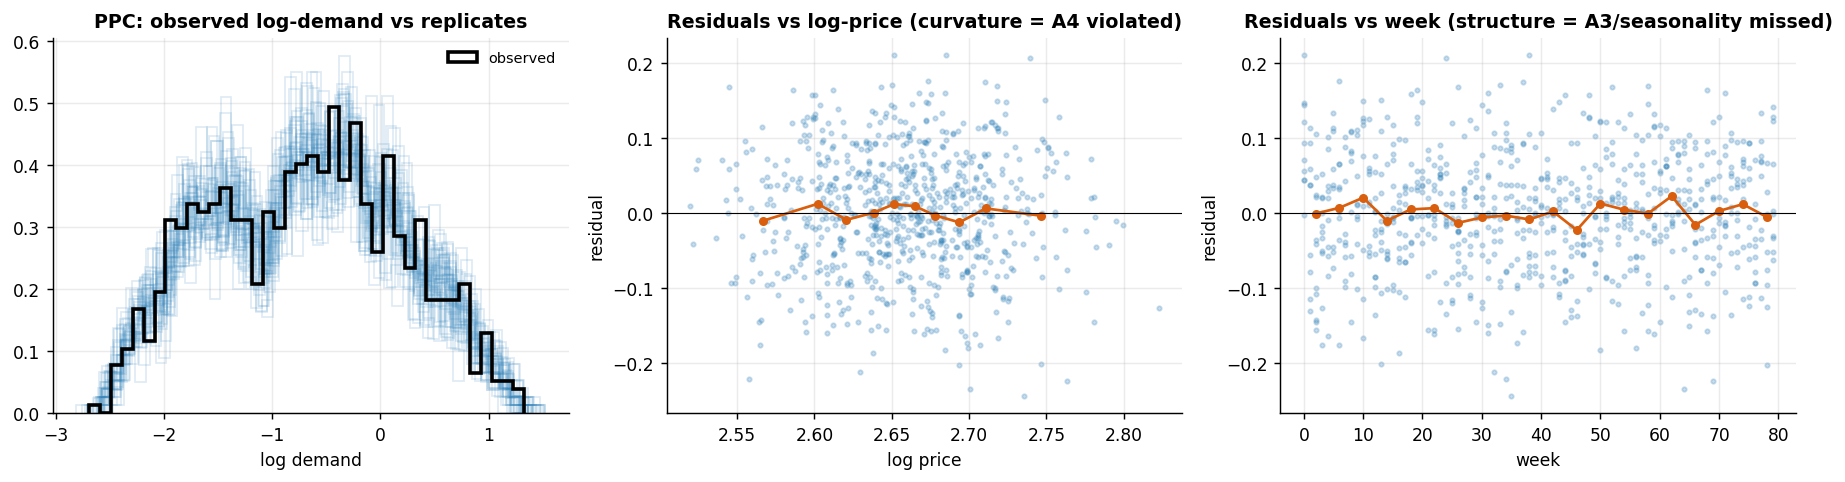

In [7]:
# Posterior predictive: thin the posterior (the plot needs ~40 replicate datasets, not thousands).
step = max(1, idata.posterior.sizes["draw"] // (60 if FAST else 200))
idata_thin = idata.sel(draw=slice(None, None, step))
with model:
    ppc = pm.sample_posterior_predictive(idata_thin, random_seed=SEED, progressbar=False)
y_rep = ppc.posterior_predictive["obs"].values.reshape(-1, len(ld))

# Posterior-mean residuals (point diagnostics; the PPC handles full-uncertainty checking)
a_hat = idata.posterior["alpha_r"].values.reshape(-1, R).mean(0)
g_hat = idata.posterior["gamma"].values.reshape(-1, z.shape[1]).mean(0)
resid = ld - (a_hat[r_idx] + partial[r_idx] * lp + z @ g_hat)
wk = df["week"].values

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
plots.ppc_plot(ax[0], ld, y_rep, title="PPC: observed log-demand vs replicates")
ax[0].set_xlabel("log demand")
qb = np.quantile(lp, np.linspace(0, 1, 11)); ib = np.clip(np.searchsorted(qb, lp, side="right") - 1, 0, 9)
ax[1].scatter(lp, resid, s=6, alpha=0.25, color=plots.BLUE)
ax[1].plot(pd.Series(lp).groupby(ib).mean().values, pd.Series(resid).groupby(ib).mean().values,
           "o-", color=plots.ORANGE, lw=1.5, ms=4)
ax[1].axhline(0, color="k", lw=0.6); ax[1].set_xlabel("log price"); ax[1].set_ylabel("residual")
ax[1].set_title("Residuals vs log-price (curvature = A4 violated)")
ax[2].scatter(wk, resid, s=6, alpha=0.25, color=plots.BLUE)
wm = pd.Series(resid).groupby(wk // 4)
ax[2].plot(wm.mean().index * 4 + 2, wm.mean().values, "o-", color=plots.ORANGE, lw=1.5, ms=4)
ax[2].axhline(0, color="k", lw=0.6); ax[2].set_xlabel("week"); ax[2].set_ylabel("residual")
ax[2].set_title("Residuals vs week (structure = A3/seasonality missed)")
fig.tight_layout()

# Formal A4 probe: pooled OLS with region dummies + controls + a curvature term in log-price.
lp_c2 = (lp - lp.mean()) ** 2
Xq = np.column_stack([np.eye(R)[r_idx], lp, lp_c2, z])
coef_q = np.linalg.lstsq(Xq, ld, rcond=None)[0]
dof = len(ld) - Xq.shape[1]
s2_q = float(((ld - Xq @ coef_q) ** 2).sum()) / dof
se_q = float(np.sqrt(s2_q * np.linalg.inv(Xq.T @ Xq)[R + 1, R + 1]))
verdict = ("consistent with zero -> constant elasticity survives in-sample"
           if abs(coef_q[R + 1]) < 2 * se_q else "SIGNIFICANT -> constant elasticity is suspect")
print(f"A4 curvature probe — coefficient on (log P − mean)²: {coef_q[R+1]:+.1f} (SE {se_q:.1f}, "
      f"t = {coef_q[R+1]/se_q:+.1f}) → {verdict}")
print("note the wide SE: with only ±5% price wiggle this test has little power far from current prices —")
print("another reason to treat any P* outside the observed range as extrapolation, not measurement.")
print(f"PPC replicate mean {y_rep.mean():.2f} vs observed {ld.mean():.2f}; replicate SD {y_rep.std():.2f} vs observed {ld.std():.2f}")

**How to read the three panels.** *Left* — the black observed log-demand density sits inside the blue
cloud of posterior replicates: the model reproduces the location, spread and shape of the outcome. *Middle*
— residuals vs log-price show no systematic bend: the binned means (orange) hug the zero line across the
observed price range, so constant elasticity is consistent with the data *where we have data*. *Right* —
residuals vs week show no leftover seasonal wave or drift; the sine/trend controls are doing their job. The
curvature probe printed under the figure makes the middle panel formal — and its wide standard error is
itself informative: with only ±5% of price variation, in-sample data can never certify the demand shape far
from current prices. **None of this validates A1 (exogeneity):** the step-8 model passes every one of
these checks while being badly wrong about the causal slope.

## 6 · Validate — recovery, shrinkage, and calibration

Estimated vs true elasticity should track the 45° line; the thin regions' point estimates get
pulled toward the fleet mean (that's pooling protecting us), and the credible intervals are
wider where data is thin. We also check that the 90% intervals actually **cover** the true
elasticities (calibration).


MAE — no pool 0.33, complete 0.27, partial 0.21  ·  coverage 75%
coverage split — thin regions (0–2): 2/3 covered · rich regions: 7/9 covered
with only 12 regions, a perfectly calibrated 90% interval covers 9 or fewer with probability 0.11 → within Monte-Carlo noise of calibrated


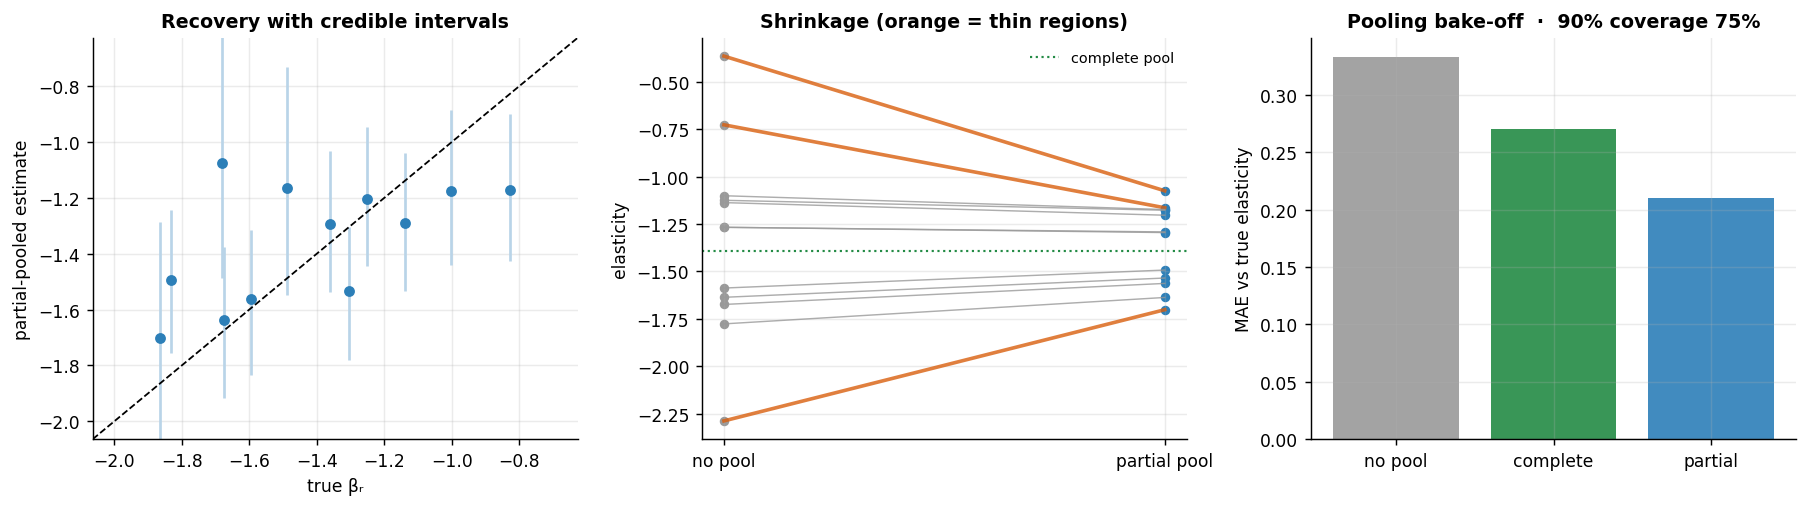

In [8]:
est_lo, est_hi = np.quantile(beta_post, [0.05, 0.95], 0)
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
# (1) recovery with CIs (forest-style vs truth)
ax[0].errorbar(true_elast, partial, yerr=[partial-est_lo, est_hi-partial], fmt="o", color=plots.BLUE, ecolor="#b9d4e8", ms=5)
lim=[min(true_elast.min(),partial.min())-.2, max(true_elast.max(),partial.max())+.2]
ax[0].plot(lim, lim, "k--", lw=1); ax[0].set_xlim(lim); ax[0].set_ylim(lim)
ax[0].set_xlabel("true βᵣ"); ax[0].set_ylabel("partial-pooled estimate"); ax[0].set_title("Recovery with credible intervals")
# (2) shrinkage: no-pool -> partial-pool, thin regions pulled hardest
for i in range(R):
    lw = 2.0 if i < 3 else 0.8
    ax[1].plot([0,1],[nopool[i],partial[i]], color=(plots.ORANGE if i<3 else plots.GREY), lw=lw, alpha=0.8)
ax[1].axhline(complete, color=plots.GREEN, ls=":", lw=1.2, label="complete pool")
ax[1].scatter(np.zeros(R), nopool, color=plots.GREY, s=18); ax[1].scatter(np.ones(R), partial, color=plots.BLUE, s=18)
ax[1].set_xticks([0,1]); ax[1].set_xticklabels(["no pool","partial pool"]); ax[1].set_ylabel("elasticity")
ax[1].set_title("Shrinkage (orange = thin regions)"); ax[1].legend(frameon=False, fontsize=8)
# (3) calibration + MAE
hits = (est_lo <= true_elast) & (true_elast <= est_hi)
cover = hits.mean()
mae = {"no pool": np.abs(nopool-true_elast).mean(), "complete": np.abs(complete-true_elast).mean(),
       "partial": np.abs(partial-true_elast).mean()}
ax[2].bar(list(mae.keys()), list(mae.values()), color=[plots.GREY, plots.GREEN, plots.BLUE], alpha=0.9)
ax[2].set_ylabel("MAE vs true elasticity"); ax[2].set_title(f"Pooling bake-off  ·  90% coverage {cover:.0%}")
fig.tight_layout()
print(f"MAE — no pool {mae['no pool']:.2f}, complete {mae['complete']:.2f}, partial {mae['partial']:.2f}  ·  coverage {cover:.0%}")

# Where do the interval misses live, and is the shortfall even signal? (see prose below)
thin = np.arange(R) < 3
p_asbad = stats.binom.cdf(int(hits.sum()), R, 0.90)   # P(a truly-90% method covers this few or fewer)
print(f"coverage split — thin regions (0–2): {int(hits[thin].sum())}/3 covered · rich regions: {int(hits[~thin].sum())}/9 covered")
print(f"with only {R} regions, a perfectly calibrated 90% interval covers {int(hits.sum())} or fewer with probability "
      f"{p_asbad:.2f} → {'within Monte-Carlo noise of calibrated' if p_asbad > 0.05 else 'a real shortfall, not just noise'}")

thin regions — predicted shrinkage [0.74 0.61 0.42], realized [0.72 0.63 0.69]
rich regions — predicted 0.26 on average, realized 0.32 (0 region(s) hidden: no-pool slope already ≈ fleet mean, so the ratio is ill-defined)


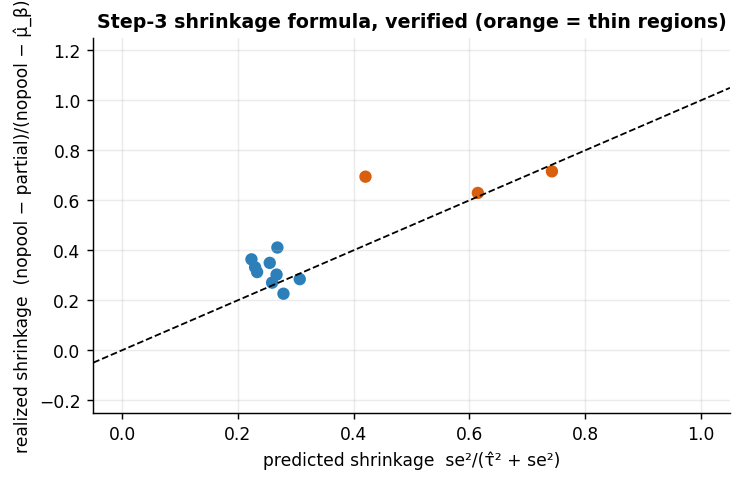

In [9]:
# Close the loop on step 3's shrinkage formula. Predicted pull toward the fleet for region r:
#   w_r = se_r^2 / (tau^2 + se_r^2)   (se_r = no-pool OLS slope standard error, tau = posterior tau_beta)
# Realized pull: how far the posterior actually moved the no-pool slope toward the fleet-level mu_beta.
tau_hat = float(idata.posterior["tau_beta"].values.mean())
mu_hat = float(idata.posterior["mu_beta"].values.mean())
se_np = np.empty(R)
for i in range(R):
    m = r_idx == i
    Xi = np.column_stack([np.ones(int(m.sum())), lp[m], z[m]])
    ci = np.linalg.lstsq(Xi, ld[m], rcond=None)[0]
    s2i = float(((ld[m] - Xi @ ci) ** 2).sum()) / (int(m.sum()) - Xi.shape[1])
    se_np[i] = np.sqrt(s2i * np.linalg.inv(Xi.T @ Xi)[1, 1])
w_pred = se_np ** 2 / (tau_hat ** 2 + se_np ** 2)
w_real = (nopool - partial) / (nopool - mu_hat)
valid = np.abs(nopool - mu_hat) > 0.05          # realized ratio is ill-defined when OLS already sits on the fleet mean

fig, ax = plt.subplots(figsize=(5.8, 3.8))
cols = np.where(np.arange(R) < 3, plots.ORANGE, plots.BLUE)
ax.scatter(w_pred[valid], w_real[valid], c=cols[valid], s=34)
ax.plot([-0.05, 1.05], [-0.05, 1.05], "k--", lw=1)
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.25, 1.25)
ax.set_xlabel("predicted shrinkage  se²/(τ̂² + se²)"); ax.set_ylabel("realized shrinkage  (nopool − partial)/(nopool − μ̂_β)")
ax.set_title("Step-3 shrinkage formula, verified (orange = thin regions)")
fig.tight_layout()
print(f"thin regions — predicted shrinkage {np.round(w_pred[:3], 2)}, realized {np.round(w_real[:3], 2)}")
print(f"rich regions — predicted {w_pred[3:].mean():.2f} on average, realized {np.nanmean(np.clip(w_real[3:], -1, 2)):.2f} "
      f"({int((~valid).sum())} region(s) hidden: no-pool slope already ≈ fleet mean, so the ratio is ill-defined)")

**How to read those panels.** *Left* — partial-pooled estimates track the true elasticities along the
45° line, and the error bars are visibly wider for the thin regions (less data → more honest uncertainty).
*Middle* — the shrinkage in action: lines connect each region's noisy no-pool estimate (left) to its
partial-pooled estimate (right); the **thin regions (orange) get yanked hardest** toward the fleet, while
data-rich regions barely budge. That selective pull is exactly the protection partial pooling buys. *Right*
— the bottom line: mean absolute error against the truth is **lowest for partial pooling**, beating both
extremes *even now that the baselines get the same controls* — no-pooling is noisy, complete-pooling is
biased, and the remaining gap is the pooling choice alone. **This bar chart is one panel**, though, and one
panel is an anecdote: 5x re-runs the whole bake-off on 25 fresh ones (with a full hierarchical refit each
time) and reports the win *and* its spread. Read that before quoting a margin from this figure.

**Is the below-nominal coverage a bug?** Don't wave it away — check it, twice; both checks are printed
under the figure. The **split** locates any misses: shrinkage intervals are calibrated for the
*ensemble*, not for each pre-shrinkage slope, so intervals run too narrow precisely for regions whose
true elasticity sits far from the fleet mean and for the hard-shrunk thin ones. The **binomial line**
asks whether the shortfall is even signal: with 12 regions, a perfectly calibrated 90% procedure still
misses a couple regularly, and the printed probability says on which side of that line this run falls.
When it flags a *real* shortfall, that is the known price of shrinkage — slightly overconfident
**per-region** intervals bought in exchange for the best **point** estimates (lowest MAE, right panel) —
worth knowing before quoting an interval to a region manager, and one more reason the decision rules in
step 7 lean on $P(\beta_r < -1)$ across the whole posterior rather than on interval endpoints. The
follow-up scatter then closes the loop on step 3's shrinkage formula: the predicted pull
$se_r^2/(\hat\tau_\beta^2+se_r^2)$ — which is exactly the step-3 factor rewritten, since $se_r$ stands in for $\sqrt{\sigma^2/n_r}$ and $1-\tau^2/(\tau^2+se^2)=se^2/(\tau^2+se^2)$ — broadly tracks the pull the posterior actually applied (near the 45° line — the approximate se-based formula is roughest for the smallest-n region), thin
regions (orange) toward the heavy-shrinkage corner — the formula we asked you to trust in step 3 is the
formula the sampler obeyed.

### 5x · Point estimate vs posterior — what the Bayesian layer actually bought

Step 0 gave the classical arm both of its options for a per-region elasticity: **complete pooling** (one
number, quoted twelve times) and **no pooling** (twelve independent regressions, three of them on 16
weeks). §4 gave the Bayesian arm the third: **partial pooling**. All three target the identical estimand
under the identical assumptions. Below they meet, region by region, and are graded against the planted
truth — and then against the only question the business actually asked.

The decision rules put a fair, *unhelpful-to-us* version of the classical arm on the field. §7's rule is
$\mathbb P(\beta_r<-1)>0.9$ — a **one-sided 90%** requirement — so the classical arms are scored on the
**one-sided 90% confidence bound**, $\hat\beta_r + t_{0.90,\,\mathrm{df}}\,\hat{se}_r < -1$: the same
90%, on the same side. (The tempting alternative — "the two-sided 90% CI lies below $-1$" — is secretly a
one-sided **95%** test, a stricter bar, and scoring the classical arm there would win the argument with a
threshold instead of an estimator. The cell prints both, so you can see exactly what that costs.) If the
posterior's advantage is real, it has to show up against the *matched* bar.

In [10]:
# --- 5x · The classical arms vs the Bayesian posterior, on the SAME estimand ---
# COMPLETE POOLING = Step 0's fleet_cl: one beta for all 12 regions.
# NO POOLING       = one OLS per region, on that region's weeks alone (same controls, HC1).
# PARTIAL POOLING  = section 4's hierarchical posterior (beta_post).
npool = cl.no_pooling(df, formula="log_demand ~ log_price + z_comp + z_season + z_trend",
                      target="log_price", group="region", cov="HC1").set_index("region").reindex(regions)
np_est, np_lo, np_hi = npool["estimate"].values, npool["lo"].values, npool["hi"].values
p_el = (beta_post < -1).mean(0)                       # the posterior quantity section 7's rule is written in
truth_el = true_elast < -1                            # ground truth: which regions ARE elastic

# (the COMPLETE-POOLING column is omitted: it is the same number, fleet_cl, in every row.)
print(f"complete pooling says {fleet_cl.estimate:+.2f} for every region below "
      f"[90% CI {fleet_cl.ci[0]:+.2f}, {fleet_cl.ci[1]:+.2f}].\n")
print(f"{'region':<10}{'n':>4}{'true':>7}{'no-pool':>9}{'  no-pool 90% CI':<18}"
      f"{'partial':>8}{'  partial 90% CrI':<19}{'P(β<−1)':>8}")
for i, rg in enumerate(regions):
    print(f"{rg:<10}{int(npool['n'].iloc[i]):>4}{true_elast[i]:>7.2f}{np_est[i]:>9.2f}"
          f"  [{np_lo[i]:+.2f}, {np_hi[i]:+.2f}]{partial[i]:>8.2f}"
          f"  [{est_lo[i]:+.2f}, {est_hi[i]:+.2f}]{p_el[i]:>8.2f}")

mae_ = {"no pooling": np.abs(np_est - true_elast).mean(),
        "complete pooling": np.abs(fleet_cl.estimate - true_elast).mean(),
        "partial pooling": np.abs(partial - true_elast).mean()}
print(f"\nACCURACY (MAE vs the twelve planted betas) — reproducing section 6's bake-off with the cl toolkit:")
for k, v in mae_.items():
    print(f"  {k:<18s} {v:.3f}")
best = min(mae_, key=mae_.get)
print(f"  -> best: {best}; on THIS panel partial pooling beats the better classical arm by "
      f"{100 * (1 - mae_['partial pooling'] / min(mae_['no pooling'], mae_['complete pooling'])):+.0f}%.")
print(f"     ONE panel, one seed, twelve regions, no interval — exactly the reasoning Step 0 refused.")
print(f"     The next cell re-runs all three arms on fresh panels; quote THAT number, not this one.")
w = int(np.argmax(np.abs(np_est - true_elast)))
print(f"  the no-pooling arm's worst region is {regions[w]} ({int(npool['n'].iloc[w])} weeks): it estimates "
      f"{np_est[w]:+.2f} against a true {true_elast[w]:+.2f};")
print(f"  the hierarchical model, borrowing from the fleet, puts it at {partial[w]:+.2f}.")
print(f"  interval width (mean): no-pool {np.mean(np_hi - np_lo):.2f}  vs  posterior "
      f"{np.mean(est_hi - est_lo):.2f}; on the three THIN regions "
      f"{np.mean((np_hi - np_lo)[:3]):.2f} vs {np.mean((est_hi - est_lo)[:3]):.2f}.")

# --- The decision, which is the only grade that matters: "price this region?" ---
# MATCH THE BARS, or the comparison is rigged. Section 7's rule, P(β_r < −1) > 0.9, is a ONE-SIDED 90%
# requirement. Its like-for-like classical partner is the ONE-SIDED 90% upper confidence bound:
#       est + t(0.90, df) · se  <  −1        (df = n_r − 5: intercept + log_price + 3 controls)
# NOT "the two-sided 90% CI lies below −1" (np_hi < −1) — that uses t at 0.95, i.e. a one-sided *95%*
# test, a STRICTLY STRICTER bar. Scoring the classical arm there and the posterior at 0.9 would flatter
# the posterior with the threshold rather than the estimator. We print both, and name the gap.
np_dof = npool["n"].values - 5
np_ub90 = np_est + stats.t.ppf(0.90, np_dof) * npool["se"].values      # one-sided 90% upper bound
act_np = np_ub90 < -1.0                                # MATCHED to section 7's 0.9
act_np_strict = np_hi < -1.0                           # the mismatched, stricter bar — for contrast only
act_cp = np.full(R, fleet_cl.ci[1] < -1.0)             # complete pooling: one verdict, imposed on everyone
act_pp = p_el > 0.9                                    # section 7's actual rule
print(f"\nTHE DECISION — of the {int(truth_el.sum())} genuinely elastic regions (β < −1), how many does each")
print(f"arm act on, and does it wrongly act on the {int((~truth_el).sum())} that is not?")
print(f"  {'arm':<44}{'acts on':>9}{'correct':>9}{'WRONG':>7}{'missed':>8}")
for lab, m in (("classical · complete pooling (1-sided 90% bound)", act_cp),
               ("classical · no pooling (1-sided 90% bound)", act_np),
               ("Bayesian · partial pooling (P > 0.9)", act_pp)):
    print(f"  {lab:<44}{int(m.sum()):>9}{int((m & truth_el).sum()):>9}"
          f"{int((m & ~truth_el).sum()):>7}{int((~m & truth_el).sum()):>8}")

flip = [regions[i] for i in range(R) if act_np[i] and not act_np_strict[i]]
print(f"\n  THE BAR IS NOT THE ESTIMATOR. Score the same no-pooling fits on 'the TWO-SIDED 90% CI lies below")
print(f"  −1' instead — the natural-looking choice, and a one-sided 95% test — and the arm acts on only "
      f"{int(act_np_strict.sum())},")
print(f"  not {int(act_np.sum())}: {', '.join(flip)} drop out on the threshold alone "
      f"(their 1-sided 90% bounds are "
      f"{', '.join(f'{np_ub90[regions.index(r_)]:+.2f}' for r_ in flip)}, just past −1).")
print(f"  Held at the SAME 90%, the honest scoreline is classical {int(act_np.sum())} vs Bayesian "
      f"{int(act_pp.sum())} — a gap of "
      f"{int(act_pp.sum()) - int(act_np.sum())} region(s), not the {int(act_pp.sum()) - int(act_np_strict.sum())} "
      f"the mismatched bar would have sold you.")

print("\n  ...and the column that does not exist. The two classical rows are now scored at the SAME 90%")
print("  as the posterior — the counts are like-for-like. But matching the *level* does not make them the")
print("  same *quantity*. 'The one-sided 90% bound clears −1' is a property of the PROCEDURE (90% of such")
print("  bounds cover the truth in repeated sampling); it is not a probability that THIS region is elastic.")
print("  Only the last column emits a number in [0,1] about the elasticity itself — the number section 7's")
print("  rule, and its 0.5 'controlled test' tier, are actually written in.")

complete pooling says -1.39 for every region below [90% CI -1.54, -1.24].

region       n   true  no-pool  no-pool 90% CI   partial  partial 90% CrI   P(β<−1)
region_00   16  -1.68    -0.36  [-1.31, +0.58]   -1.07  [-1.49, -0.56]    0.64
region_01   16  -1.86    -2.29  [-2.65, -1.93]   -1.70  [-2.23, -1.29]    1.00
region_02   16  -1.49    -0.73  [-1.11, -0.34]   -1.16  [-1.55, -0.73]    0.75
region_03   80  -1.25    -1.14  [-1.46, -0.82]   -1.20  [-1.45, -0.95]    0.91
region_04   80  -1.00    -1.12  [-1.51, -0.74]   -1.18  [-1.44, -0.89]    0.84
region_05   80  -1.36    -1.27  [-1.54, -1.00]   -1.29  [-1.54, -1.03]    0.97
region_06   80  -1.59    -1.67  [-1.93, -1.42]   -1.56  [-1.84, -1.32]    1.00
region_07   80  -1.67    -1.78  [-2.09, -1.46]   -1.64  [-1.92, -1.37]    1.00
region_08   80  -1.14    -1.27  [-1.56, -0.98]   -1.29  [-1.53, -1.04]    0.97
region_09   80  -0.83    -1.10  [-1.46, -0.74]   -1.17  [-1.42, -0.90]    0.86
region_10   80  -1.30    -1.64  [-1.90, -1.37]   -1

In [11]:
# --- One panel is one panel. The MAE bake-off above is a single seed, twelve regions, no interval —
# and Step 0 already refused to read bias off one draw. Same discipline here: re-run ALL THREE arms on
# the SAME NSEED fresh panels Step 0 used (seeds 1000+), each thinned exactly as section 2 thinned this
# one, each with a FULL hierarchical refit at the notebook's own FIT settings — no lower bar for the
# headline number than for the ladder that made it.
def fresh_panel(seed):
    """A fresh clean panel, thinned in regions 0–2 exactly as section 2 thins the working one."""
    d, te = dgp.price_panel(n_regions=12, n_weeks=80, confounder_strength=0.0, seed=seed)
    d["log_price"], d["log_demand"] = np.log(d["price"]), np.log(d["demand"])
    regs = sorted(d["region"].unique())
    ri = d["region"].map({r_: i for i, r_ in enumerate(regs)}).values
    keep = np.ones(len(d), bool)
    for i in [0, 1, 2]:
        idx = np.where(ri == i)[0]
        keep[np.random.default_rng(i).choice(idx, size=int(len(idx) * 0.8), replace=False)] = False
    d, ri = d[keep].reset_index(drop=True), ri[keep]
    zz = d[["competitor_price", "season", "trend"]].values; zz = (zz - zz.mean(0)) / zz.std(0)
    d["z_comp"], d["z_season"], d["z_trend"] = zz[:, 0], zz[:, 1], zz[:, 2]
    return d, ri, zz, te, regs

mae_s = {k: [] for k in ("no pooling", "complete pooling", "partial pooling")}
rhat_worst, div_tot = 0.0, 0
for s_ in range(NSEED):
    d_, ri_, zz_, te_, regs_ = fresh_panel(1000 + s_)
    lp_, ld_ = d_["log_price"].values, d_["log_demand"].values
    npo_ = cl.no_pooling(d_, formula="log_demand ~ log_price + z_comp + z_season + z_trend",
                         target="log_price", group="region", cov="HC1").set_index("region").reindex(regs_)
    cpo_ = cl.ols(d_, F_FULL, target="log_price", cov="cluster", cluster="region")
    with pm.Model():                                    # section 4's model, verbatim
        mb_ = pm.Normal("mu_beta", -1.0, 1.0); tb_ = pm.HalfNormal("tau_beta", 1.0)
        br_ = pm.Normal("beta_r", mb_, tb_, shape=R); ar_ = pm.Normal("alpha_r", 0, 5, shape=R)
        g_ = pm.Normal("gamma", 0, 2, shape=3); sg_ = pm.HalfNormal("sigma", 1.0)
        pm.Normal("obs", mu=ar_[ri_] + br_[ri_] * lp_ + zz_ @ g_, sigma=sg_, observed=ld_)
        id_ = pm.sample(random_seed=SEED, progressbar=False, **FIT)
    cr_ = est.convergence_report(id_, var_names=["mu_beta", "tau_beta", "sigma"])
    rhat_worst = max(rhat_worst, cr_["max_rhat"]); div_tot += int(cr_["n_divergences"] or 0)
    pp_ = id_.posterior["beta_r"].values.reshape(-1, R).mean(0)
    mae_s["no pooling"].append(float(np.abs(npo_["estimate"].values - te_).mean()))
    mae_s["complete pooling"].append(float(np.abs(cpo_.estimate - te_).mean()))
    mae_s["partial pooling"].append(float(np.abs(pp_ - te_).mean()))

M = {k: np.array(v) for k, v in mae_s.items()}
best_cl = np.minimum(M["no pooling"], M["complete pooling"])          # the better classical arm, PER PANEL
gain = 100.0 * (1.0 - M["partial pooling"] / best_cl)                 # partial pooling's edge, per panel
wins = M["partial pooling"] < best_cl
gain_1 = 100.0 * (1 - mae_["partial pooling"] / min(mae_["no pooling"], mae_["complete pooling"]))
pctile = 100.0 * float((gain < gain_1).mean())                        # where seed 5 sits in the spread
print(f"MAE vs the planted betas over {NSEED} FRESH panels (each one a full hierarchical refit) — mean ± sd:")
for k in ("no pooling", "complete pooling", "partial pooling"):
    print(f"  {k:<18s} {M[k].mean():.3f} ± {M[k].std():.3f}   (this panel, seed {SEED}: {mae_[k]:.3f})")
print(f"  -> partial pooling beats the better classical arm on {int(wins.sum())}/{NSEED} panels, by "
      f"{gain.mean():+.0f}% on average")
print(f"     (sd {gain.std():.0f} pp; worst panel {gain.min():+.0f}%, best {gain.max():+.0f}%).")
print(f"  -> the single-seed headline above ({gain_1:+.0f}%) sits at the {pctile:.0f}th percentile of that")
print(f"     spread — so quote the multi-panel line, never the one-panel one.")
# The comparator above is the ORACLE-best classical arm, re-picked panel by panel against the planted
# truth — an advantage no analyst has. Partial pooling has to beat whichever extreme got lucky. Head to
# head against each arm separately, and against the arm that is actually the one to beat on average:
w_np = int((M["partial pooling"] < M["no pooling"]).sum())
w_cp = int((M["partial pooling"] < M["complete pooling"]).sum())
print(f"  -> head-to-head: partial pooling beats no pooling on {w_np}/{NSEED} panels, complete pooling "
      f"on {w_cp}/{NSEED}.")
best_1 = min(("no pooling", "complete pooling"), key=lambda k: mae_[k])
best_m = min(("no pooling", "complete pooling"), key=lambda k: M[k].mean())
print(f"  -> and WHICH classical arm is the one to beat is itself a one-seed artefact: on this panel it is")
print(f"     {best_1} ({mae_[best_1]:.3f}), but averaged over {NSEED} panels it is {best_m} "
      f"({M[best_m].mean():.3f} vs {M['complete pooling' if best_m == 'no pooling' else 'no pooling'].mean():.3f}).")
print(f"  (convergence across all {NSEED} refits: max r-hat {rhat_worst:.3f}, {div_tot} divergences in total.)")

MAE vs the planted betas over 25 FRESH panels (each one a full hierarchical refit) — mean ± sd:
  no pooling         0.190 ± 0.054   (this panel, seed 5: 0.333)
  complete pooling   0.292 ± 0.065   (this panel, seed 5: 0.270)
  partial pooling    0.159 ± 0.036   (this panel, seed 5: 0.210)
  -> partial pooling beats the better classical arm on 19/25 panels, by +9% on average
     (sd 24 pp; worst panel -63%, best +43%).
  -> the single-seed headline above (+22%) sits at the 68th percentile of that
     spread — so quote the multi-panel line, never the one-panel one.
  -> head-to-head: partial pooling beats no pooling on 19/25 panels, complete pooling on 25/25.
  -> and WHICH classical arm is the one to beat is itself a one-seed artefact: on this panel it is
     complete pooling (0.270), but averaged over 25 panels it is no pooling (0.190 vs 0.292).
  (convergence across all 25 refits: max r-hat 1.010, 25 divergences in total.)


**The honest verdict — what the posterior bought, and what it did not.**

**1 · On the fleet number, they agree — say it plainly.** Step 0's pooled OLS and §4's posterior
$\mu_\beta$ land on essentially the same fleet elasticity, both within a hair of the planted truth. That
is not a disappointment; it is the lesson. **The causal work was done by the identification, not by the
machinery.** With 768 region-weeks and weak priors, a Bayesian hierarchy is not going to move a
well-identified pooled slope, and it does not. If you came here hoping "going Bayesian" would improve the
headline number, this is the correction.

**2 · On the *twelve* numbers, partial pooling wins — but read the 25-panel line, not this panel's.**
The single-panel MAE block above is seductive, and it is *one draw*. Step 0 spent ten lines refusing to
read bias off one panel ("one sample cannot separate bias from luck"), and the headline number does not
get an exemption: the cell above re-runs **all three arms on 25 fresh panels**, each with a full
hierarchical refit at the same sampler settings. The win is real, and it is smaller and noisier than this
panel advertised:

- Partial pooling has the **lowest mean MAE** of the three (≈0.16, against ≈0.19 for no pooling and ≈0.29
  for complete pooling) *and* the **smallest seed-to-seed spread**. It is the most accurate arm and the
  most stable one — the two things you want from an estimator you will re-run every quarter.
- It beats the better classical arm on **19 of 25 panels**, and that comparator is deliberately
  *unhelpful to us*: it is the **oracle-best** classical arm, re-chosen panel by panel against the planted
  truth an analyst would never have. Partial pooling has to beat whichever extreme happened to get lucky.
- The average margin is **+9%, not the +22% this panel prints** (sd ≈24 pp; on its worst panel partial
  pooling is *worse* by 63%). Seed 5 sits around the 68th percentile of that spread. **The estimator wins;
  the headline was flattered by the draw.** Six panels in twenty-five, it loses.
- And the 25 panels overturn something else this table implies. *Which classical arm is the one to beat is
  itself a one-seed artefact.* Here complete pooling (0.270) looks better than no pooling (0.333) — but
  only because region_00's sixteen weeks produced a spectacular miss (−0.36 against a true −1.68) that
  drags the no-pooling average up single-handed. Averaged over panels the ranking **reverses**: no pooling
  0.190, complete pooling 0.292. With 80 weeks in nine of twelve regions, "trust each region's own data"
  is usually the better classical bet, and complete pooling's identical-for-everyone bias is the steadier
  drag. The blow-up in the table is the *anecdote*; the mean is the *fact*.

So the claim survives contact with 25 panels, and it lands quieter than one panel would let you say it:
partial pooling interpolates between the two extremes with a weight the data chooses ($\tau_\beta$), and
that interpolation is worth roughly **9% of MAE on average and a visibly tighter spread** — not 22%.
**This is still the one place in the notebook where the Bayesian layer moves the estimate, and it moves it
because the classical toolbox has no third option to offer** — not because its arithmetic is better. (A
frequentist mixed model would get close; it is, after all, the same likelihood. The point stands that
plain OLS cannot.)

**3 · On the decision, the classical arm *can* play — once you stop rigging the bar.** §7's rule is
$\mathbb P(\beta_r<-1)\ge0.9$: a **one-sided 90%** requirement. The tempting way to score the classical
arm is *"its 90% CI lies entirely below $-1$"* — and it is the wrong way. A two-sided 90% interval puts 5%
in each tail, so that test is secretly a one-sided **95%** bar: strictly stricter than what the posterior
is being asked to clear. Score the arms that way and the posterior "wins" **8 regions to 5** — and three of
those regions were handed over by the *threshold*, not won by the *estimator*. Scored where it belongs, on
the matched one-sided 90% bound $\hat\beta_r + t_{0.90,\mathrm{df}}\,\hat{se}_r < -1$ (same 90%, same
side), no pooling acts on **7** regions against the posterior's **8**, and *neither arm ever prices the one
truly inelastic region*. region_05 and region_08 — bounds $-1.06$ and $-1.04$ — were never "missed by the
classical estimator"; they were missed by a mismatched bar. **The honest gap is one region.** It still
points the same way, which is why the notebook's conclusion survives; it just stops being inflated.

Where the classical arm *does* fail on this decision, it fails expensively, and fair scoring does not save
it: **complete pooling's bound also clears $-1$, so it certifies all twelve regions as elastic** —
including the one the DGP planted as genuinely *inelastic*, which would get a price rise it cannot
support. That is a **wrong** action, not a missed one, and it is the only wrong action anywhere in the
table. No pooling, scored fairly, leaves 4 of the 11 elastic regions on the table; the posterior leaves 3.
On counts, that is a rounding error — and it is the right moment to stop pretending the win is about
counts.

**And the dial exists — it simply does not turn the knob the CMO needs.** It would be convenient to say
the classical arm has no threshold to tune. It has one: $\alpha$. An analyst can build an 80% bound, or
test at any level she likes, and the roster re-sorts — exactly as the posterior's roster re-sorts when the
action bar moves from 0.9 to 0.8. The difference is *what the two dials control*. Turning $\alpha$ tunes
the **long-run error rate of the procedure**: at $\alpha=0.1$, one in ten bounds built this way lands on
the wrong side of the truth, **across hypothetical repetitions of the whole study**. It cannot be set to a
statement of risk appetite about **region_05 in particular**, because "the probability region_05 is
elastic" is not a quantity the procedure emits — region_05's bound either clears $-1$ or it does not, and
which of those happened is not something the interval can tell you. The posterior's dial is the other
thing entirely: $\mathbb P(\beta_{05}<-1)=0.97$ is a number **about that region**, in the only sample we
have, and moving the bar to 0.8 changes *which regions we are willing to be wrong about, and how often*.
Matching the **level** of the two bars — which 5x does, honestly — does not make them the same
**quantity**. That is the durable difference, and it is the one that survives the corrected scoreline.

That is also what pays for §7's third tier. Because each region arrives with a number in $[0,1]$, the
pricing rule can **route** it: act above 0.9, run a **controlled test** between 0.5 and 0.9, hold below.
A confidence bound has no "how sure are we" to report — it is in or out — so the classical arm can only
build a two-tier policy. The posterior's three misses are not a failure; they are a **choice**, made
against a stated probability, and the regions it holds back are the ones §7 sends to a price test rather
than abandons.

**What Bayes did NOT buy here.** Not the fleet elasticity (Step 0 had it, correctly, with an honest
clustered interval). Not a better standard error — clustering already told us the pooled model was
misspecified, which was the *same message* the hierarchy acts on, just delivered without a way to respond
to it. Not protection from endogeneity: the §4 posterior is exactly as biased as the OLS slope when A1
fails (§8 proves it), and the fix is an instrument, which Step 0 fit with no prior in sight. Not, on a
matched bar, a landslide on the decision count: that margin is **one region**, and the 8-vs-5 scoreline a
mismatched threshold would have handed us was not a finding, it was an accounting error. What it *did* buy
is the **third pooling regime** — worth ~9% of MAE on average, and a materially tighter spread across
panels — and the **probability statement**: twelve honest per-region elasticities instead of one, and a
$\mathbb P(\beta_r<-1)$ per region that a pricing rule can actually be written in. On the euros, the edge
over a fairly-scored classical arm is narrow. On the **vocabulary**, the gap is total — and it is the
vocabulary, not the euros, that lets §7 run a three-tier *set / test / hold* policy instead of a coin
flip. That is the entire win, honestly sized. For this business problem, it is still the one worth having.

## 7 · Decide, in euros — profit-maximising price per region

The decision-maker's question is not "what is $\beta$?" but "**what price do I set?**" For
constant-elasticity demand $Q(P) = A P^{\beta}$ and constant marginal cost $c$, weekly profit is

$$
\pi(P) \;=\; (P - c)\, Q(P) \;=\; (P - c)\, A P^{\beta}.
$$

Differentiate and set to zero:

$$
\frac{d\pi}{dP} \;=\; A P^{\beta} \;+\; (P - c)\,\beta A P^{\beta-1}
\;=\; A P^{\beta-1}\big[(\beta+1)\,P \;-\; \beta c\big] \;=\; 0
\quad\Longrightarrow\quad
P^\star \;=\; \frac{\beta}{\beta+1}\, c ,
$$

valid **only when $\beta < -1$** (demand elastic). The bracket $(\beta+1)P - \beta c$ then starts positive
at small $P$ and decreases through zero — profit rises, peaks at $P^\star$, falls: a genuine maximum
(that sign change *is* the second-order condition). For $-1 \le \beta < 0$ the bracket stays positive for
every $P>0$, so the model says "raise price without limit" — which really means *the constant-elasticity
model has left its domain of validity*, not that infinite prices are optimal.

Rearranged, $P^\star$ is the classic **Lerner index** (markup) rule:

$$
\frac{P^\star - c}{P^\star} \;=\; -\frac{1}{\beta}
$$

— *optimal markup over cost equals the inverse elasticity*, the oldest one-liner in pricing: $\beta=-2$
prices at twice cost, $\beta=-1.5$ at three times cost. And note the **blow-up as $\beta \to -1^{-}$**:
the denominator $\beta+1 \to 0^-$ and $P^\star \to +\infty$. Posterior draws near $-1$ therefore produce
wild optimal prices — the statistical reason (exploited below) why regions whose elasticity posterior
straddles $-1$ get routed to a **controlled test**, not a price move.

We propagate the **elasticity posterior** draw-by-draw into a **price posterior** and a **profit-uplift
posterior** per region, and — the honest part — flag regions where we're not confident demand is even
elastic ($\beta<-1$) for that test rather than acting on a shaky slope.

   region  elasticity  P(elastic) P* €     P* 90% CI  uplift %          action
region_00       -1.07        0.64    —             —        34 controlled test
region_01       -1.70        1.00 19.9  [14.5, 35.6]        13       set price
region_02       -1.16        0.75    —             —        35 controlled test
region_03       -1.20        0.91 43.7 [25.7, 220.7]        46       set price
region_04       -1.18        0.84    —             —        43 controlled test
region_05       -1.29        0.97 34.2 [22.8, 111.5]        36       set price
region_06       -1.56        1.00 22.4  [17.6, 33.3]        16       set price
region_07       -1.64        1.00 20.6  [16.7, 29.3]        12       set price
region_08       -1.29        0.97 34.6 [22.9, 107.8]        37       set price
region_09       -1.17        0.86    —             —        45 controlled test
region_10       -1.53        1.00 23.1  [18.2, 34.2]        17       set price
region_11       -1.49        1.00 24.5  [18.6, 40.7]

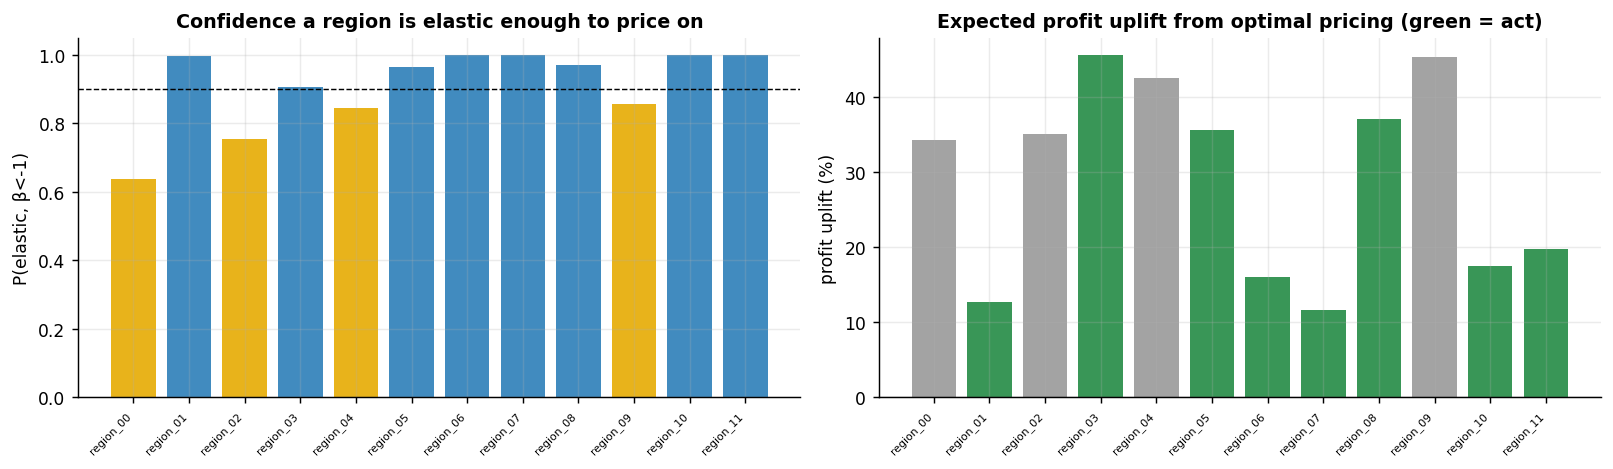

In [12]:
MARGINAL_COST = 8.0
p_elastic = (beta_post < -1).mean(0)                                   # P(region is elastic, beta<-1)
P0 = df.groupby("region")["price"].mean().reindex(regions).values      # current price per region
Q0 = df.groupby("region")["demand"].mean().reindex(regions).values     # current weekly quantity (a normalized index)

# Per posterior DRAW so elasticity, optimal price and profit uplift stay consistent (the naive version
# mixed an unconditional-mean elasticity with a conditional-on-elastic optimal price). Monopoly optimum
# under constant-elasticity demand is P* = c*beta/(beta+1) for beta<-1; profit(P)=(P-c)*Q0*(P/P0)**beta.
# We report the uplift as a %% of current profit — scale-free, so it does not depend on the demand units.
def uplift_pct(beta, p0, c=MARGINAL_COST):
    elastic = beta < -1.001
    pstar = np.where(elastic, c * beta / (beta + 1.0), p0)
    ratio = ((pstar - c) * (pstar / p0) ** beta) / (p0 - c)             # profstar/prof0 (Q0 cancels)
    return np.where(elastic, 100.0 * (ratio - 1.0), 0.0)               # act only where elastic, else 0%%

def pstar_q(b, c=MARGINAL_COST, qs=(0.05, 0.5, 0.95)):
    b_el = b[b < -1.001]                                                # the formula's domain: elastic draws only
    return np.quantile(c * b_el / (b_el + 1.0), qs)

rows = []; fleet_pct = []
for i in range(R):
    up = uplift_pct(beta_post[:, i], P0[i]); conf = float((beta_post[:, i] < -1).mean())
    act = "set price" if conf > 0.9 else ("controlled test" if conf > 0.5 else "hold/test")
    if conf > 0.9:
        ps = pstar_q(beta_post[:, i])
        pstar_med, pstar_ci = f"{ps[1]:.1f}", f"[{ps[0]:.1f}, {ps[2]:.1f}]"
    else:                                                              # no price published for test-routed regions
        pstar_med, pstar_ci = "—", "—"
    if conf > 0.9: fleet_pct.append(up)
    # P(uplift>0) equals P(elastic) by construction (P* is the profit optimum), so it is
    # not repeated as a column -- keeps each printed row inside the page width.
    rows.append({"region": regions[i], "elasticity": round(partial[i], 2), "P(elastic)": round(conf, 2),
                 "P* €": pstar_med, "P* 90% CI": pstar_ci,
                 "uplift %": round(float(up.mean())), "action": act})
tbl = pd.DataFrame(rows)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.7))
ax[0].bar(range(R), p_elastic, color=[plots.BLUE if c_>0.9 else (plots.GOLD if c_>0.5 else plots.ORANGE) for c_ in p_elastic], alpha=0.9)
ax[0].axhline(0.9, color="k", ls="--", lw=0.8); ax[0].set_xticks(range(R)); ax[0].set_xticklabels(regions, rotation=45, ha="right", fontsize=6)
ax[0].set_ylabel("P(elastic, β<-1)"); ax[0].set_title("Confidence a region is elastic enough to price on")
up_means = [float(uplift_pct(beta_post[:, i], P0[i]).mean()) for i in range(R)]
ax[1].bar(range(R), up_means, color=[plots.GREEN if p_elastic[i]>0.9 else plots.GREY for i in range(R)], alpha=0.9)
ax[1].axhline(0, color="k", lw=0.6); ax[1].set_xticks(range(R)); ax[1].set_xticklabels(regions, rotation=45, ha="right", fontsize=6)
ax[1].set_ylabel("profit uplift (%)"); ax[1].set_title("Expected profit uplift from optimal pricing (green = act)")
fig.tight_layout()
print(tbl.to_string(index=False))
fleet = np.mean(fleet_pct, axis=0) if fleet_pct else np.zeros(beta_post.shape[0])
print(f"\nAcross the {len(fleet_pct)} confidently-elastic regions, moving to optimal pricing lifts profit by "
      f"{fleet.mean():+.0f}%\n[90% {np.quantile(fleet,.05):+.0f}%, {np.quantile(fleet,.95):+.0f}%] on average — the pricing "
      f"change's value, scale-free and with uncertainty carried through (assumes constant elasticity out to P*; see caveats).")

# The Jensen/boundary illustration the prose below leans on — computed, never asserted:
weak_i = int(np.argmin(p_elastic)); strong_i = int(np.argmax(p_elastic))
bmean = float(beta_post[:, weak_i].mean())
plug = MARGINAL_COST * bmean / (bmean + 1.0)
plug_txt = f"€{plug:.0f}" if bmean < -1 else f"€{plug:.0f} (formula already outside its β<−1 domain)"
pstar_strong = float(pstar_q(beta_post[:, strong_i])[1])
up_w = uplift_pct(beta_post[:, weak_i], P0[weak_i]); conf_w = float((beta_post[:, weak_i] < -1).mean())
print(f"\npoint-plug illustration — weakest region {regions[weak_i]}: P(elastic) = {conf_w:.2f}, mean β = {bmean:.2f};")
print(f"plugging that mean into P* = cβ/(β+1) gives {plug_txt}, vs €{pstar_strong:.0f} for the most confident region ({regions[strong_i]}).")
print(f"its expected uplift {up_w.mean():+.0f}% is diluted by the {1-conf_w:.0%} of draws pinned at 0%; conditional on truly")
print(f"being elastic it is {up_w.mean()/max(conf_w, 1e-9):+.0f}% — a big, *unreliable* number, which is exactly why it goes to a test.")

Green band = prices ever charged; the model was only ever tested there (step 5). Both P₀ (dotted) and the
median P* (orange) matter less than the SHAPE: a flat top means a mis-estimated β costs little profit;
curves that fan out and keep rising off the right edge mean the 'optimum' is an extrapolated guess.


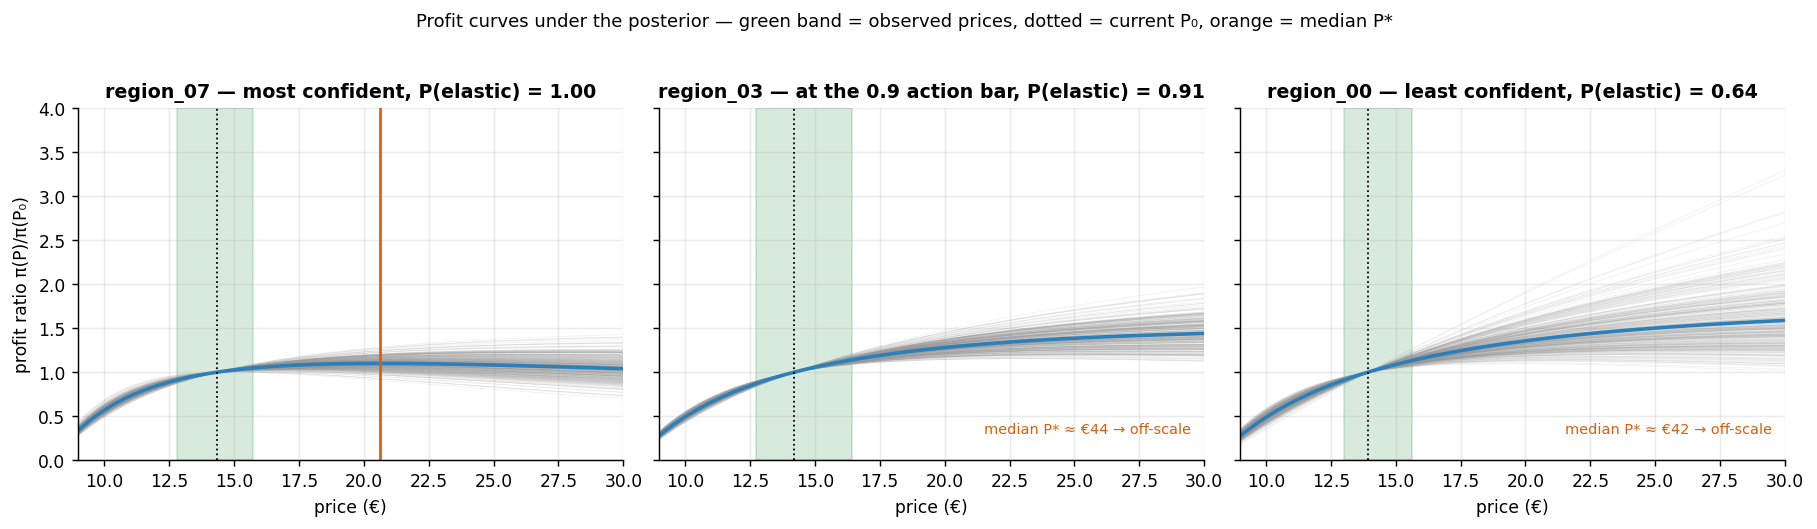

In [13]:
# Profit-ratio curves pi(P)/pi(P0) for three representative regions: the most confident, one sitting
# at the 0.9 action bar, and the least confident. Grey = individual posterior draws (each one a full profit curve), blue = the posterior-median
# curve, green band = the price range we actually OBSERVED — everything outside it rides on the
# constant-elasticity assumption (A4) alone.
pr_range = df.groupby("region")["price"].agg(["min", "max"])
order = np.argsort(p_elastic)
picks = [int(order[-1]), int(np.argmin(np.abs(p_elastic - 0.9))), int(order[0])]
labels = ["most confident", "at the 0.9 action bar", "least confident"]
if len(set(picks)) < 3:                     # degenerate posterior ordering: fall back to spread picks
    picks = [int(order[-1]), int(order[R // 2]), int(order[0])]
Pgrid = np.linspace(9.0, 30.0, 160)
n_show = 150 if FAST else 300
sel = np.random.default_rng(SEED).choice(beta_post.shape[0], size=min(n_show, beta_post.shape[0]), replace=False)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.9), sharey=True)
for k, (i, lab) in enumerate(zip(picks, labels)):
    p0 = P0[i]
    curves = (Pgrid[None, :] - MARGINAL_COST) * (Pgrid[None, :] / p0) ** beta_post[sel, i][:, None] / (p0 - MARGINAL_COST)
    med = (Pgrid - MARGINAL_COST) * (Pgrid / p0) ** float(np.median(beta_post[:, i])) / (p0 - MARGINAL_COST)
    ax[k].plot(Pgrid, curves.T, color=plots.GREY, lw=0.4, alpha=0.15)
    ax[k].plot(Pgrid, med, color=plots.BLUE, lw=2)
    ax[k].axvspan(pr_range.loc[regions[i], "min"], pr_range.loc[regions[i], "max"], color=plots.GREEN, alpha=0.18)
    ax[k].axvline(p0, color="k", ls=":", lw=1)
    if p_elastic[i] > 0.5:
        ps_med = float(pstar_q(beta_post[:, i])[1])
        if ps_med <= Pgrid.max():           # keep panels on a common, comparable price axis
            ax[k].axvline(ps_med, color=plots.ORANGE, lw=1.5)
        else:
            ax[k].annotate(f"median P* ≈ €{ps_med:.0f} → off-scale", xy=(Pgrid.max() - 0.5, 0.3),
                           ha="right", fontsize=8, color=plots.ORANGE)
    ax[k].set_xlim(Pgrid.min(), Pgrid.max())
    ax[k].set_ylim(0, 4); ax[k].set_xlabel("price (€)")
    ax[k].set_title(f"{regions[i]} — {lab}, P(elastic) = {p_elastic[i]:.2f}")
ax[0].set_ylabel("profit ratio π(P)/π(P₀)")
fig.suptitle("Profit curves under the posterior — green band = observed prices, dotted = current P₀, orange = median P*",
             y=1.03, fontsize=10)
fig.tight_layout()
print("Green band = prices ever charged; the model was only ever tested there (step 5). Both P₀ (dotted) and the")
print("median P* (orange) matter less than the SHAPE: a flat top means a mis-estimated β costs little profit;")
print("curves that fan out and keep rising off the right edge mean the 'optimum' is an extrapolated guess.")

**How to read the decision table and the two panels.** *Left* — each bar is $P(\beta<-1)$, our
posterior confidence that a region's demand is **elastic** enough to price on: **blue** clears the 0.9
line (*set price*), **gold** sits in 0.5–0.9 (*controlled test*), **orange** is below 0.5 (*hold/test*).
*Right* — the expected **profit uplift** from moving to the optimal price, **green** only where we are
confident enough to act. The fleet number underneath averages the uplift across the confidently-elastic
regions and carries the posterior through to a 90% interval. The **P\*** columns are the number the CMO
actually signs: the posterior-median optimal price with its 90% credible interval — printed *only* for
regions confident enough to act on ("—" elsewhere: publishing a price for a region we just routed to a
test would invite exactly the mistake this notebook is built to prevent).

**One subtlety worth saying out loud** — the kind a sharp audience member will probe. The "profit uplift %"
is a **posterior mean over *every* draw**, with the non-elastic draws ($\beta\ge-1$, where raising price
doesn't pay) contributing **0%**. So it is an *expected* uplift already discounted by our uncertainty — not
"the uplift once we act". For the confident **set price** rows ($P(\text{elastic})\approx 1$) the two
coincide; for the weakest region — see the *point-plug illustration* printed under the table — the expected
uplift is diluted by the slice of draws worth 0%, and the uplift *conditional on the region truly being
elastic* (also printed) is far larger and far shakier.

This is also why you **cannot reproduce the uplift column by plugging the row's own elasticity into the
formula.** The closed form $P^\star=c\,\beta/(\beta+1)$ blows up as $\beta\to-1^-$: the printed
illustration plugs the weakest region's *mean* elasticity into the formula and gets an absurd price, a
world away from the sane optima of the well-elastic regions. So the per-draw uplift has a heavy right tail
and its **mean is not the formula evaluated at the mean elasticity** (**Jensen's inequality** — for a curved function the average of the outputs is not the function of the average input; here $P^\star$ bends so sharply near $\beta=-1$ that the mean of the per-draw uplifts sits well above the uplift computed at the mean $\beta$). We deliberately propagate the *whole* posterior rather than point-plug a single slope — and
that very instability near $\beta=-1$ is the statistical reason those low-confidence regions are routed to
a **controlled test**, not to a price move we might regret.

**The profit curves make the same point visually.** In the *most confident* panel the grey posterior
curves agree on a gentle hill with a **flat top**: even a sizeable error in $\beta$ moves profit little
near $P^\star$, so acting is low-risk. In the *least confident* panel the curves fan out and many keep
rising off the right edge — the model is begging for a price far outside the green band of prices we have
ever charged, on a functional form (A4) we could only test *inside* that band; statistical risk and
extrapolation risk stack, so it goes to a test. The *middle* panel sits near the 0.9 action bar and is the
boundary case the thresholds are built around: most draws agree on a gentle hill, but a visible minority
still explode off to the right — whether it clears the bar is decided by the printed $P(\beta<-1)$, and
standing this close to the threshold is itself an argument for measuring before committing. And notice one sobering detail: even for confident regions
$P^\star$ typically sits *above* the observed price band — the recommendation itself is an extrapolation.
That is why a staged rollout (move a minority of stores first, watch a few weeks) beats a fleet-wide
overnight change even where the posterior is sure.

### The cost assumption — the other number in the formula

$P^\star = c\,\beta/(\beta+1)$ is **linear in marginal cost $c$**: a ±25% error in $c$ moves *every*
recommended price by ±25%, no posterior required. Cost is usually handed to the analyst as a single
accounting number, and it deserves the same scepticism as the elasticity — arguably more, because nothing
in the data can check it. Below we sweep $c$ ±25% around our €8 and recompute the whole decision layer.
Two things to watch: the **action routing never changes** (it keys off $P(\beta<-1)$, which involves no
$c$), but every $P^\star$ and every uplift number moves — so if finance restates the cost, the
*set-vs-test split* survives while the price list is rewritten wholesale. Cost measurement is as
decision-critical as the elasticity itself.

In [14]:
cost_grid = np.array([6.0, 7.0, 8.0, 9.0, 10.0]) if FAST else np.round(np.linspace(6.0, 10.0, 9), 1)
set_idx = [i for i in range(R) if p_elastic[i] > 0.9]
rows_c = []
for c_ in cost_grid:
    fleet_c = np.mean([uplift_pct(beta_post[:, i], P0[i], c=c_) for i in set_idx], axis=0)
    med_ps = [float(pstar_q(beta_post[:, i], c=c_)[1]) for i in set_idx]
    rows_c.append({"marginal cost €": c_, "n set-price": len(set_idx),
                   "median P* range €": f"{min(med_ps):.1f}–{max(med_ps):.1f}",
                   "fleet uplift %": round(float(fleet_c.mean())),
                   "uplift 90% CI": f"[{np.quantile(fleet_c, .05):+.0f}%, {np.quantile(fleet_c, .95):+.0f}%]"})
print(pd.DataFrame(rows_c).to_string(index=False))
print("\nreading it: the set-price roster is c-invariant by construction (column 2 never moves), and every")
print("median P* scales exactly linearly in c — get the cost 25% wrong and every recommended price is 25% wrong,")
print("with the uplift estimate moving too. Before signing the price list, audit the cost number.")

 marginal cost €  n set-price median P* range €  fleet uplift % uplift 90% CI
             6.0            8         14.9–32.8               8   [+3%, +14%]
             6.5            8         16.2–35.5              10   [+5%, +18%]
             7.0            8         17.4–38.2              14   [+7%, +22%]
             7.5            8         18.7–41.0              19  [+11%, +28%]
             8.0            8         19.9–43.7              24  [+15%, +35%]
             8.5            8         21.1–46.4              32  [+20%, +44%]
             9.0            8         22.4–49.1              40  [+27%, +55%]
             9.5            8         23.6–51.9              51  [+36%, +68%]
            10.0            8         24.9–54.6              65  [+47%, +84%]

reading it: the set-price roster is c-invariant by construction (column 2 never moves), and every
median P* scales exactly linearly in c — get the cost 25% wrong and every recommended price is 25% wrong,
with the uplift

## 8 · Caveats — what partial pooling does *not* fix

Partial pooling handles *noise*, not *bias*. If price is endogenous to an **unobserved** demand shock,
adjusting for observed $Z$ isn't enough and the elasticity is biased **toward zero** — by step 3's OVB
formula, $\hat\beta \to \beta + \kappa\sigma_u^2/(\kappa^2\sigma_u^2 + \sigma_\nu^2)$. We now do three
things: **(i)** switch the hidden shock on at the demo strength $\kappa=1.2$ and refit the full
hierarchical model, checking the observed bias against the formula; **(ii)** sweep $\kappa$ to map the
whole bias curve — a range, not an anecdote; **(iii)** return to the **IV cure Step 0 already fit** — the same $\kappa=1.2$ panel, the same planted
cost shifter — and read what it costs.
(These re-runs use the **full** panel, not the thinned subset used above — which only sharpens the fleet
estimate and doesn't change the bias point being made.)

clean fleet elasticity -1.36 (true -1.42)
endogenous fleet elasticity -0.59 (true -1.42) → biased toward zero by +0.83
OVB formula check — predicted bias +0.83 vs observed +0.83: the bias is computable, not mysterious.
endogenous-fit convergence: max r-hat 1.000 - min ESS 5640 - divergences 0
the Bayesian hierarchy is no protection: its fleet elasticity (-0.59) sits within 0.01 of naive OLS
on the SAME raw kappa = 1.2 panel (-0.60) — partial pooling shrinks NOISE, and this is BIAS.
  (Step 0's -0.63 is that same OLS on the instrument-augmented panel — the one with the cost shifter
  added to log-price — so it differs by 0.03. Same story, different panel; the panel below is Step 0's.)
Fix = an instrument (a cost shifter) or a natural price experiment — Step 0 fit it; the bargain is priced below.


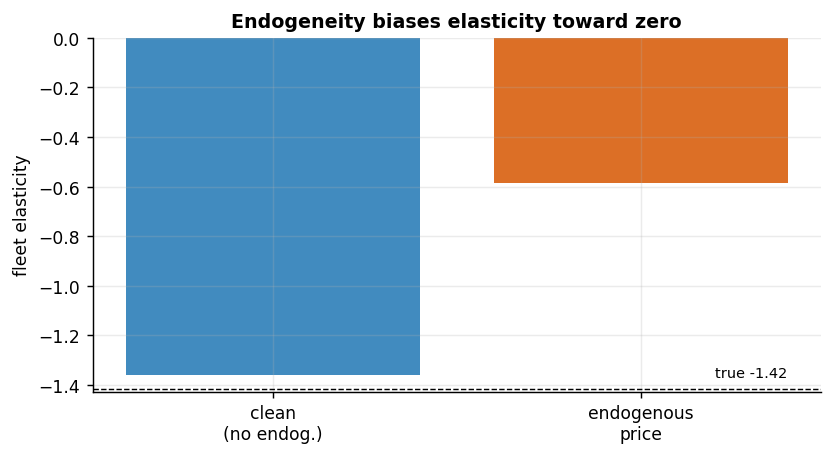

In [15]:
# The kappa = 1.2 panel (df2, lp2, ld2, r2, z2) and its planted instrument were built in STEP 0, where the
# classical arm already read it. Here we refit the FULL hierarchical model on it -- same model as section 4,
# same priors -- to show that partial pooling inherits the bias exactly as OLS does.
with pm.Model():
    mb=pm.Normal("mb",-1,1); tb=pm.HalfNormal("tb",1); br=pm.Normal("br",mb,tb,shape=R)
    ar=pm.Normal("ar",0,5,shape=R); g=pm.Normal("g",0,2,shape=3); s=pm.HalfNormal("s",1)
    pm.Normal("o", mu=ar[r2]+br[r2]*lp2+z2@g, sigma=s, observed=ld2)
    id2=pm.sample(random_seed=SEED,progressbar=False,**FIT)
biased = id2.posterior["br"].values.reshape(-1,R).mean(0)
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.bar(["clean\n(no endog.)","endogenous\nprice"], [partial.mean(), biased.mean()], color=[plots.BLUE, plots.ORANGE], alpha=0.9)
ax.axhline(true_elast.mean(), color="k", ls="--", lw=0.8); ax.text(1.4, true_elast.mean()+0.05, f"true {true_elast.mean():.2f}", ha="right", fontsize=8)
ax.set_ylabel("fleet elasticity"); ax.set_title("Endogeneity biases elasticity toward zero"); fig.tight_layout()
print(f"clean fleet elasticity {partial.mean():.2f} (true {true_elast.mean():.2f})")
obs_bias = float(biased.mean() - true2.mean())
print(f"endogenous fleet elasticity {biased.mean():.2f} (true {true2.mean():.2f}) → biased toward zero by {obs_bias:+.2f}")
# Verify step 3's OVB arithmetic: kappa=1.2, sigma_u=1, sigma_nu=0.05 — all planted in the DGP.
kappa_demo, sig_nu = 1.2, 0.05
pred_bias = kappa_demo / (kappa_demo**2 + sig_nu**2)
print(f"OVB formula check — predicted bias +{pred_bias:.2f} vs observed {obs_bias:+.2f}: the bias is computable, not mysterious.")
print(f"endogenous-fit convergence: {est.convergence_report(id2)['summary']}")
# The LIKE-FOR-LIKE classical twin: naive pooled OLS on THIS panel — the raw kappa = 1.2 df2, with no
# cost shifter in it. (Step 0's beta_ols is the same fit on the *instrument-augmented* panel, whose
# log-price carries the extra 0.25·W term; close, but not the same data. Compare on the same data.)
_d2 = pd.DataFrame({"log_demand": ld2, "log_price": lp2, "region": df2["region"].values,
                    "z_comp": z2[:, 0], "z_season": z2[:, 1], "z_trend": z2[:, 2]})
_D2 = pd.get_dummies(_d2["region"], prefix="reg", drop_first=True).astype(float)
_d2 = pd.concat([_d2, _D2], axis=1)
ols_raw = cl.ols(_d2, "log_demand ~ log_price + z_comp + z_season + z_trend + " + " + ".join(_D2.columns),
                 target="log_price", cov="cluster", cluster="region")
print(f"the Bayesian hierarchy is no protection: its fleet elasticity ({biased.mean():+.2f}) sits within "
      f"{abs(biased.mean() - ols_raw.estimate):.2f} of naive OLS\non the SAME raw kappa = 1.2 panel "
      f"({ols_raw.estimate:+.2f}) — partial pooling shrinks NOISE, and this is BIAS.")
print(f"  (Step 0's {beta_ols:+.2f} is that same OLS on the instrument-augmented panel — the one with the "
      f"cost shifter\n  added to log-price — so it differs by {abs(beta_ols - ols_raw.estimate):.2f}. "
      f"Same story, different panel; the panel below is Step 0's.)")
print("Fix = an instrument (a cost shifter) or a natural price experiment — Step 0 fit it; the bargain is priced below.")

**From a point to a curve.** One $\kappa$ is an anecdote. Below we sweep the endogeneity strength from 0
to 1.25 — regenerating the panel and re-estimating the fleet elasticity at each value (a
controls-included pooled OLS with region intercepts stands in for the full hierarchical refit: it agrees
with it at the $\kappa=1.2$ point above and costs milliseconds instead of minutes) — and overlay the OVB
*prediction* from step 3. Watch two things. **(i)** The estimate does not drift gently: because the
exogenous price wiggle is tiny ($\sigma_\nu = 0.05$), even a faint hidden shock swamps it — the bias term
$\kappa\sigma_u^2/(\kappa^2\sigma_u^2+\sigma_\nu^2)$ peaks near $\kappa\approx\sigma_\nu$ — and the
fitted "demand curve" actually slopes *upward* over a whole range of $\kappa$. **(ii)** The recommendation
flips almost immediately: the moment the estimate crosses the $\beta=-1$ decision line, "set optimal
prices in elastic regions" becomes "demand looks inelastic — hold everywhere". Endogeneity doesn't just
shade the number; it reverses the pricing call.

estimated fleet elasticity by κ:  κ=0: -1.45 · κ=0.01: +2.45 · κ=0.0128933: +3.31 · κ=0.0166237: +4.31 · κ=0.0214334: +5.41 · κ=0.0276347: +6.50 · κ=0.0356302: +7.41 · κ=0.0459391: +7.92 · κ=0.0592306: +7.90 · κ=0.0763677: +7.33 · κ=0.098463: +6.37 · κ=0.126951: +5.22 · κ=0.163682: +4.06 · κ=0.21104: +3.00 · κ=0.2721: +2.10 · κ=0.350826: +1.35 · κ=0.45233: +0.75 · κ=0.583202: +0.27 · κ=0.751939: -0.11 · κ=0.969497: -0.40 · κ=1.25: -0.63
the estimate is already on the wrong side of β=−1 by κ ≈ 0.01: a hidden shock explaining only ~4% of residual price variance flips the pricing call fleet-wide.
the grey dashed curve is step 3's OVB formula — theory and refit agree across the whole sweep,
including the perverse region where the fitted demand curve slopes upward.


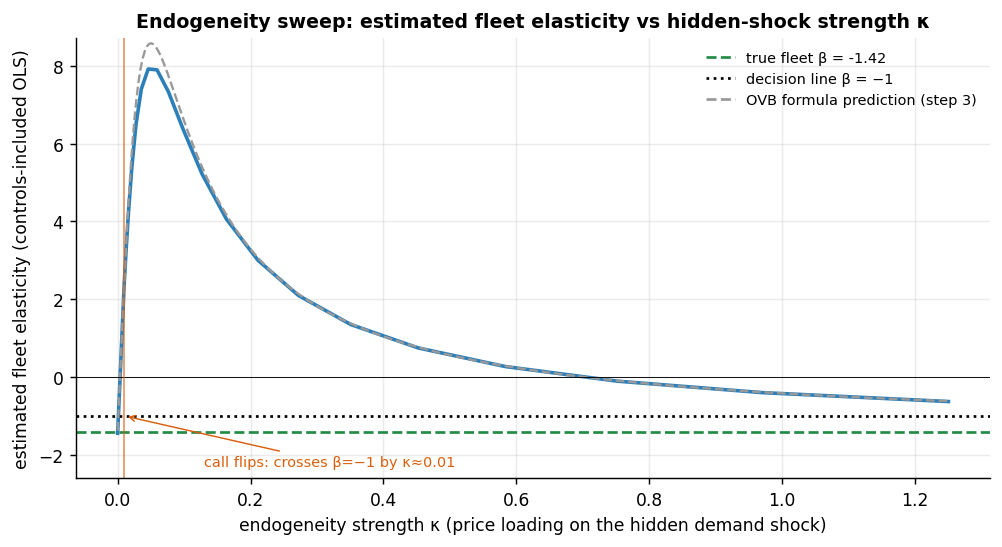

In [16]:
kappas = (np.array([0.0, 0.02, 0.05, 0.1, 0.2, 0.4, 0.7, 1.0, 1.25]) if FAST
          else np.concatenate([[0.0], np.geomspace(0.01, 1.25, 20)]))

def fleet_ols(kappa):
    d, _ = dgp.price_panel(n_regions=12, n_weeks=80, confounder_strength=float(kappa), seed=SEED)
    lpk, ldk = np.log(d["price"].values), np.log(d["demand"].values)
    rk = d["region"].map({r: i for i, r in enumerate(regions)}).values
    zk = d[["competitor_price", "season", "trend"]].values; zk = (zk - zk.mean(0)) / zk.std(0)
    return float(np.linalg.lstsq(np.column_stack([np.eye(R)[rk], lpk, zk]), ldk, rcond=None)[0][R])

betas_k = np.array([fleet_ols(k) for k in kappas])
sig_nu = 0.05
kfine = np.linspace(1e-4, kappas.max(), 400)
ovb_pred = true_elast.mean() + kfine / (kfine**2 + sig_nu**2)          # step-3 formula, sigma_u = 1
cross = float(kappas[np.argmax(betas_k > -1.0)]) if np.any(betas_k > -1.0) else float("nan")

fig, ax = plt.subplots(figsize=(7.8, 4.3))
plots.sensitivity_plot(ax, kappas, betas_k, true_elast.mean(), -1.0, tipping=None,
                       title="Endogeneity sweep: estimated fleet elasticity vs hidden-shock strength κ")
ax.plot(kfine, ovb_pred, color=plots.GREY, ls="--", lw=1.3)
ax.axhline(0, color="k", lw=0.5)
ax.axvline(cross, color=plots.ORANGE, lw=0.9, alpha=0.7)
ax.set_ylim(min(betas_k.min(), -2.6), betas_k.max() + 0.8)
ax.annotate(f"call flips: crosses β=−1 by κ≈{cross:g}", xy=(cross, -1.0), xytext=(cross + 0.12, -2.3),
            fontsize=8, color=plots.ORANGE, arrowprops=dict(arrowstyle="->", color=plots.ORANGE, lw=0.8))
ax.set_xlabel("endogeneity strength κ (price loading on the hidden demand shock)")
ax.set_ylabel("estimated fleet elasticity (controls-included OLS)")
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles + [plt.Line2D([], [], color=plots.GREY, ls="--")],
          [f"true fleet β = {true_elast.mean():.2f}", "decision line β = −1", "OVB formula prediction (step 3)"],
          frameon=False, fontsize=8)
fig.tight_layout()
print("estimated fleet elasticity by κ:  " + " · ".join(f"κ={k:g}: {b:+.2f}" for k, b in zip(kappas, betas_k)))
print(f"the estimate is already on the wrong side of β=−1 by κ ≈ {cross:g}: a hidden shock explaining only "
      f"~{cross**2/(cross**2 + sig_nu**2):.0%} of residual price variance flips the pricing call fleet-wide.")
print("the grey dashed curve is step 3's OVB formula — theory and refit agree across the whole sweep,")
print("including the perverse region where the fitted demand curve slopes upward.")

### The cure, priced — the instrument from Step 0

Step 0 already did this fit, deliberately, *before* any prior appeared: the three conditions an instrument
must satisfy (relevance, exclusion, independence), the 2SLS two-stage algebra, the planted cost shifter
$W$, and `cl.iv_2sls`'s first-stage $F$ are all up there — reread them if they have faded. Nothing is
re-estimated here. What we do now is put the two classical fits side by side **with the sweep above in
mind**, because only now can we see what the instrument is actually buying and what it charges for it.

first-stage F = 27 (>10: relevant, not weak)
naive OLS: -0.63 ± 0.09 — a tight band 9 SEs from the truth -1.42 (precisely wrong)
2SLS:      -1.66 ± 0.21 — a wide band 1.1 SEs from the truth (imprecisely right)
the cure's price, in width: the 2SLS interval is x2.3 the OLS one — it keeps only the cost-driven
slice of price variation, so the hidden-shock slice drops out of the estimate, and so does most of the data.
Full treatment — robust SEs, weak-instrument diagnostics, Bayesian IV: notebook 11, and 11b on real Criteo data.


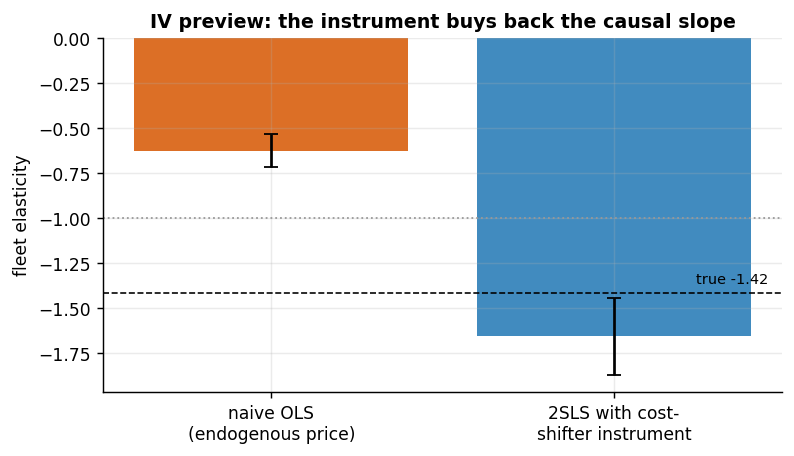

In [17]:
# NOTHING IS REFIT HERE. beta_ols/se_ols (cl.ols, region-clustered) and beta_iv/se_iv/F1 (cl.iv_2sls) all
# come from Step 0, on the same kappa = 1.2 panel with the same planted cost shifter. We only draw them.
fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.bar(["naive OLS\n(endogenous price)", "2SLS with cost-\nshifter instrument"], [beta_ols, beta_iv],
       yerr=[se_ols, se_iv], capsize=4, color=[plots.ORANGE, plots.BLUE], alpha=0.9)
ax.axhline(true2.mean(), color="k", ls="--", lw=0.9)
ax.text(1.45, true2.mean() + 0.06, f"true {true2.mean():.2f}", ha="right", fontsize=8)
ax.axhline(-1.0, color=plots.GREY, ls=":", lw=1)
ax.set_ylabel("fleet elasticity"); ax.set_title("IV preview: the instrument buys back the causal slope")
fig.tight_layout()
print(f"first-stage F = {F1:.0f} ({'>10: relevant, not weak' if F1 > 10 else '<10: WEAK — do not use'})")
print(f"naive OLS: {beta_ols:+.2f} ± {se_ols:.2f} — a tight band {abs(beta_ols - true2.mean())/se_ols:.0f} SEs from the "
      f"truth {true2.mean():+.2f} (precisely wrong)")
print(f"2SLS:      {beta_iv:+.2f} ± {se_iv:.2f} — a wide band {abs(beta_iv - true2.mean())/se_iv:.1f} SEs from the truth "
      f"(imprecisely right)")
print(f"the cure's price, in width: the 2SLS interval is x{(iv.ci[1]-iv.ci[0])/(ols_endog.ci[1]-ols_endog.ci[0]):.1f} "
      f"the OLS one — it keeps only the cost-driven")
print("slice of price variation, so the hidden-shock slice drops out of the estimate, and so does most of the data.")
print("Full treatment — robust SEs, weak-instrument diagnostics, Bayesian IV: notebook 11, and 11b on real Criteo data.")

**Reading the IV panel.** Naive OLS (orange) is **precisely wrong**: a deceptively tight standard error
around an estimate many standard errors away from the truth (the count is printed above, and it gets
*worse* if you swap the clustered SE for the more "efficient" HC1 one — Step 0 prints both) — under the
table's routing rules it would have us wrongly *hold* prices fleet-wide, with great confidence. (Its naive-OLS point sits a touch below step 6's endogenous hierarchical fit because this IV panel adds the cost-shift term — same story, slightly different panel.) 2SLS (blue) is **imprecisely right**: it lands
within a couple of its (much wider) standard errors of the planted elasticity, because it discards every
scrap of price variation except the cost-shock slice, which is clean by construction. That asymmetry is
the whole IV bargain — the cure costs **variance**: real-world IV estimates are noisier and need bigger
samples, and a *weak* instrument (first-stage $F \lesssim 10$) is worse than none, amplifying small
exclusion violations into large bias. Managing that trade-off, with honest IV uncertainty in a Bayesian
wrapper, is notebook 11's whole job; notebook 11b repeats it on real Criteo data.

**Other caveats, folded into the assumption ledger of step 3.**

- **A4 · functional form.** Log-log assumes *constant* elasticity within region. We probed it in-sample
  (step 5's curvature term — consistent with zero in this run, with the honest note that ±5% of price
  wiggle gives that test little power), but every $P^\star$ sits at or beyond the edge of the observed
  price band, where no in-sample check reaches. The staged-rollout advice of step 7 is the operational
  hedge, and elasticity should be re-estimated as the new prices generate data.
- **A3 · dynamics.** A `lag(price)` term would capture stockpiling / reference-price dynamics (omitted
  here for clarity); on real scanner data always try it — pantry-loading masquerades as high short-run
  elasticity and vanishes at longer horizons.
- **Levels vs logs — a porting trap.** The model is for $\log Q$; if you ever forecast *units*, the
  lognormal mean needs the correction $\mathbb{E}[Q \mid P] = e^{\mu + \sigma^2/2}$, not $e^{\mu}$. Our
  profit *uplift* is immune — it is a **ratio** of two expected profits with the same residual $\sigma$,
  so the $e^{\sigma^2/2}$ factor cancels in `uplift_pct` — but the moment you report absolute euros or
  units, it bites.
- **Pooling is a prior choice.** Too few regions or a mis-specified $\tau_\beta$ prior can over-pool —
  always inspect the fleet-vs-region spread ($\tau_\beta$'s posterior), and remember step 4's
  non-centered reparametrization when the sampler starts complaining.

## 9 · The one-paragraph decision

> **To the CMO.** Fleet demand is elastic — the fleet-mean elasticity lands close to −1.4 (exact value
> and credible interval in the dict below), with genuine region-to-region spread, so a single national
> price is leaving money on the table. For the majority of regions the posterior clears our 0.9 bar that
> demand is truly elastic ($\beta<-1$); for those we recommend moving toward the table's **P\*** prices —
> the expected fleet profit uplift and its 90% interval are printed under the decision table — rolled out
> to a minority of stores first, because every P\* sits at or beyond the price range we have ever
> observed. The remaining regions get **no price move**: their elasticity posterior straddles −1, where
> the optimal-price formula is unstable, so they get a **controlled price test** — randomized ±10% price
> cells for 8 weeks, deliberately manufacturing the exogenous price variation (A2) that identification
> feeds on. Three conditionals we will not hide: **(i)** everything assumes prices were not historically
> managed against demand (A1) — if they were, step 8 says the true elasticity is *more negative* than we
> estimated, so the uplift is conservative on that axis; **(ii)** the constant-elasticity extrapolation
> (A4) cuts the other way — profit at prices we never charged is model, not measurement; **(iii)** the
> recommended prices scale one-for-one with the €8 marginal-cost figure, so a cost restatement rewrites
> the price list (though not the set-vs-test split). Act where the posterior is sure; measure where it is
> not.

In [18]:
mu_d = idata.posterior["mu_beta"].values.ravel()
n_set = int((p_elastic > 0.9).sum()); n_ct = int(((p_elastic > 0.5) & (p_elastic <= 0.9)).sum())
decision = {
    "fleet_elasticity": round(float(mu_d.mean()), 2),
    "fleet_elasticity_ci90": [round(float(np.quantile(mu_d, q)), 2) for q in (0.05, 0.95)],
    "tau_beta": round(float(idata.posterior["tau_beta"].values.mean()), 2),
    "coverage90_true_beta": round(float(cover), 2),
    "n_regions": R, "n_set_price": n_set, "n_controlled_test": n_ct, "n_hold": R - n_set - n_ct,
    "fleet_uplift_pct": round(float(fleet.mean()), 1),
    "fleet_uplift_ci90_pct": [round(float(np.quantile(fleet, q)), 1) for q in (0.05, 0.95)],
    "marginal_cost_eur": MARGINAL_COST,
    "endogeneity_bias_at_kappa_1p2": round(obs_bias, 2),
    "ovb_predicted_bias_at_kappa_1p2": round(pred_bias, 2),
    "kappa_where_call_flips": round(cross, 3),
    "iv_first_stage_F": round(F1, 1),
    "beta_ols_endogenous": round(beta_ols, 2),
    "beta_iv": round(beta_iv, 2),
    "beta_iv_se": round(se_iv, 2),
    "true_fleet_elasticity_reference": round(float(true_elast.mean()), 2),
}
import re as _re
txt = json.dumps(decision, indent=2)
txt = _re.sub(r"\[\s+([^][]+?)\s+\]",                                # keep short lists on one line
              lambda m: "[" + ", ".join(s.strip() for s in m.group(1).split(",")) + "]", txt)
print(txt)

{
  "fleet_elasticity": -1.36,
  "fleet_elasticity_ci90": [-1.54, -1.17],
  "tau_beta": 0.3,
  "coverage90_true_beta": 0.75,
  "n_regions": 12,
  "n_set_price": 8,
  "n_controlled_test": 4,
  "n_hold": 0,
  "fleet_uplift_pct": 24.4,
  "fleet_uplift_ci90_pct": [15.0, 35.3],
  "marginal_cost_eur": 8.0,
  "endogeneity_bias_at_kappa_1p2": 0.83,
  "ovb_predicted_bias_at_kappa_1p2": 0.83,
  "kappa_where_call_flips": 0.01,
  "iv_first_stage_F": 27.2,
  "beta_ols_endogenous": -0.63,
  "beta_iv": -1.66,
  "beta_iv_se": 0.21,
  "true_fleet_elasticity_reference": -1.42
}


---

*The cell below exports this run's results to the book (Chapter 5 · Price elasticity). It emits scalars, booktabs tables and book-style vector figures under `cmp.report`, so that no number in the chapter is ever retyped. It changes nothing above.*

In [19]:
# ---------------------------------------------------------------- Book export (cmp.report)
# Chapter 5 of the book never retypes a number: every figure in its prose is emitted HERE, from
# this executed run, into book/build/results/nb03.json -> macros.tex (see src/cmp/report.py).
# A missing macro is a LaTeX compile error, never a silent hole. Figures are re-rendered in book
# style (vector PDF, no in-figure title — the caption does that work) and closed immediately, so
# this cell changes nothing the notebook shows above.
import matplotlib as mpl
from cmp import report as Rep

def V(k, v, **kw):
    return Rep.value(f"nb03.{k}", v, **kw)

def esc(s):                                    # region_05 -> region\_05: safe inside a LaTeX macro
    return str(s).replace("_", r"\_")

conv = est.convergence_report(idata, var_names=["mu_beta", "tau_beta", "sigma"])
mu_draws = idata.posterior["mu_beta"].values.ravel()
tau_draws = idata.posterior["tau_beta"].values.ravel()
sig_draws = idata.posterior["sigma"].values.ravel()

# --- the world, and the planted truth ---------------------------------------------------
V("n_regions", int(R), fmt="d")
V("n_weeks", 80, fmt="d")
V("n_obs", int(len(df)), fmt=",d")
V("n_thin", 3, fmt="d")
V("obs_min", int(counts.min()), fmt="d")
V("obs_max", int(counts.max()), fmt="d")
V("true_fleet", float(true_elast.mean()), fmt="+.2f")
V("true_tau", float(true_elast.std()), fmt=".2f")
V("true_beta_min", float(true_elast.min()), fmt="+.2f")
V("true_beta_max", float(true_elast.max()), fmt="+.2f")
V("n_true_elastic", int((true_elast < -1).sum()), fmt="d")
V("n_true_inelastic", int((true_elast >= -1).sum()), fmt="d")
V("inelastic_region", esc(regions[int(np.argmax(true_elast))]))
V("inelastic_beta", float(true_elast.max()), fmt="+.2f")
V("lp_sd_min", float(lp_sd.min()), fmt=".3f")
V("lp_sd_med", float(lp_sd.median()), fmt=".3f")
V("lp_sd_max", float(lp_sd.max()), fmt=".3f")

# --- Step 0 · the classical baseline ----------------------------------------------------
V("fleet_ols", float(fleet_cl.estimate), fmt="+.2f")
V("fleet_lo", float(fleet_cl.ci[0]), fmt="+.2f")
V("fleet_hi", float(fleet_cl.ci[1]), fmt="+.2f")
V("fleet_err", float(fleet_cl.estimate - true_elast.mean()), fmt="+.2f")
V("se_iid", float(fleet_id.se), fmt=".3f")
V("se_hc", float(fleet_hc.se), fmt=".3f")
V("se_cluster", float(fleet_cl.se), fmt=".3f")
V("se_ratio_hc", float(fleet_cl.se / fleet_hc.se), fmt=".2f")
V("se_ratio_iid", float(fleet_cl.se / fleet_id.se), fmt=".2f")
V("n_clusters", int(fleet_cl.extra["n_clusters"]), fmt="d")
V("nseed", int(NSEED), fmt="d")
V("bias_full", float(np.mean(errs["full"])), fmt="+.3f")
V("bias_nocomp", float(np.mean(errs["no competitor"])), fmt="+.3f")
V("bias_noseason", float(np.mean(errs["no season/trend"])), fmt="+.3f")
V("sd_full", float(np.std(errs["full"])), fmt=".3f")
V("sd_nocomp", float(np.std(errs["no competitor"])), fmt=".3f")
V("sd_noseason", float(np.std(errs["no season/trend"])), fmt=".3f")
V("se_ladder_full", float(np.mean(ses["full"])), fmt=".3f")
V("se_ladder_noseason", float(np.mean(ses["no season/trend"])), fmt=".3f")
V("se_widen", float(np.mean(ses["no season/trend"]) / np.mean(ses["full"])), fmt=".1f")
V("nopool_fleet", float(nopool.mean()), fmt="+.2f")
V("complete_fleet", float(complete), fmt="+.2f")

# --- §4 · the Bayesian model -------------------------------------------------------------
V("mu_beta", float(mu_draws.mean()), fmt="+.2f")
V("mu_beta_lo", float(np.quantile(mu_draws, 0.05)), fmt="+.2f")
V("mu_beta_hi", float(np.quantile(mu_draws, 0.95)), fmt="+.2f")
V("tau_beta", float(tau_draws.mean()), fmt=".2f")
V("tau_beta_lo", float(np.quantile(tau_draws, 0.05)), fmt=".2f")
V("tau_beta_hi", float(np.quantile(tau_draws, 0.95)), fmt=".2f")
V("sigma_post", float(sig_draws.mean()), fmt=".3f")
V("n_draws", int(FIT["draws"] * FIT["chains"]), fmt=",d")
V("rhat", float(conv["max_rhat"]), fmt=".3f")
V("ess", float(conv["min_ess_bulk"]), fmt=",.0f")
V("divergences", int(conv["n_divergences"] or 0), fmt="d")
V("mu_vs_ols", float(abs(mu_draws.mean() - fleet_cl.estimate)), fmt=".2f")

# --- §5/§6 · diagnostics and validation --------------------------------------------------
V("ppc_mean", float(y_rep.mean()), fmt=".2f")
V("ppc_sd", float(y_rep.std()), fmt=".2f")
V("obs_mean", float(ld.mean()), fmt=".2f")
V("obs_sd", float(ld.std()), fmt=".2f")
V("curv_coef", float(coef_q[R + 1]), fmt="+.1f")
V("curv_se", float(se_q), fmt=".1f")
V("curv_t", float(coef_q[R + 1] / se_q), fmt="+.1f")
V("cover", 100 * float(cover), fmt=".0f")
V("cover_hits", int(hits.sum()), fmt="d")
V("cover_thin", int(hits[thin].sum()), fmt="d")
V("cover_rich", int(hits[~thin].sum()), fmt="d")
V("p_asbad", float(p_asbad), fmt=".2f")
V("shrink_pred_thin", float(w_pred[:3].mean()), fmt=".2f")
V("shrink_real_thin", float(np.nanmean(w_real[:3])), fmt=".2f")
V("shrink_pred_rich", float(w_pred[3:].mean()), fmt=".2f")
V("shrink_real_rich", float(np.nanmean(np.clip(w_real[3:], -1, 2))), fmt=".2f")

# --- §5x · point estimate vs posterior ---------------------------------------------------
V("mae_nopool_one", float(mae_["no pooling"]), fmt=".3f")
V("mae_complete_one", float(mae_["complete pooling"]), fmt=".3f")
V("mae_partial_one", float(mae_["partial pooling"]), fmt=".3f")
V("gain_one", float(gain_1), fmt="+.0f")
V("mae_nopool", float(M["no pooling"].mean()), fmt=".3f")
V("mae_complete", float(M["complete pooling"].mean()), fmt=".3f")
V("mae_partial", float(M["partial pooling"].mean()), fmt=".3f")
V("mae_nopool_sd", float(M["no pooling"].std()), fmt=".3f")
V("mae_complete_sd", float(M["complete pooling"].std()), fmt=".3f")
V("mae_partial_sd", float(M["partial pooling"].std()), fmt=".3f")
V("gain_mean", float(gain.mean()), fmt="+.0f")
V("gain_sd", float(gain.std()), fmt=".0f")
V("gain_min", float(gain.min()), fmt="+.0f")
V("gain_max", float(gain.max()), fmt="+.0f")
V("n_wins", int(wins.sum()), fmt="d")
V("n_losses", int(NSEED - int(wins.sum())), fmt="d")
V("pctile_one", float(pctile), fmt=".0f")
V("wins_vs_nopool", int(w_np), fmt="d")
V("wins_vs_complete", int(w_cp), fmt="d")
V("best_classical_one", best_1)
V("best_classical_multi", best_m)
V("refit_rhat", float(rhat_worst), fmt=".3f")
V("refit_div", int(div_tot), fmt="d")
V("worst_region", esc(regions[w]))
V("worst_region_n", int(npool["n"].iloc[w]), fmt="d")
V("worst_nopool", float(np_est[w]), fmt="+.2f")
V("worst_true", float(true_elast[w]), fmt="+.2f")
V("worst_partial", float(partial[w]), fmt="+.2f")
V("width_nopool", float(np.mean(np_hi - np_lo)), fmt=".2f")
V("width_partial", float(np.mean(est_hi - est_lo)), fmt=".2f")
V("width_nopool_thin", float(np.mean((np_hi - np_lo)[:3])), fmt=".2f")
V("width_partial_thin", float(np.mean((est_hi - est_lo)[:3])), fmt=".2f")

V("act_cp", int(act_cp.sum()), fmt="d")
V("act_cp_correct", int((act_cp & truth_el).sum()), fmt="d")
V("act_cp_wrong", int((act_cp & ~truth_el).sum()), fmt="d")
V("act_np", int(act_np.sum()), fmt="d")
V("act_np_correct", int((act_np & truth_el).sum()), fmt="d")
V("act_np_wrong", int((act_np & ~truth_el).sum()), fmt="d")
V("act_np_missed", int((~act_np & truth_el).sum()), fmt="d")
V("act_pp", int(act_pp.sum()), fmt="d")
V("act_pp_correct", int((act_pp & truth_el).sum()), fmt="d")
V("act_pp_wrong", int((act_pp & ~truth_el).sum()), fmt="d")
V("act_pp_missed", int((~act_pp & truth_el).sum()), fmt="d")
V("act_np_strict", int(act_np_strict.sum()), fmt="d")
V("gap_honest", int(act_pp.sum()) - int(act_np.sum()), fmt="d")
V("gap_mismatched", int(act_pp.sum()) - int(act_np_strict.sum()), fmt="d")
V("n_flip", int(len(flip)), fmt="d")
V("flip_regions", " and ".join(esc(r_) for r_ in flip))
V("flip_bounds", " and ".join(f"{np_ub90[regions.index(r_)]:+.2f}" for r_ in flip))
_showcase = flip[0] if flip else regions[int(np.argmax(p_el))]
_si = regions.index(_showcase)
V("showcase_region", esc(_showcase))
V("showcase_p", float(p_el[_si]), fmt=".2f")
V("showcase_bound", float(np_ub90[_si]), fmt="+.2f")

# --- §7 · the decision, in euros ---------------------------------------------------------
V("marginal_cost", float(MARGINAL_COST), unit="EUR", fmt=".0f")
V("n_set", int((p_elastic > 0.9).sum()), fmt="d")
V("n_test", int(((p_elastic > 0.5) & (p_elastic <= 0.9)).sum()), fmt="d")
V("n_hold", int((p_elastic <= 0.5).sum()), fmt="d")
V("fleet_uplift", float(fleet.mean()), fmt="+.0f")
V("fleet_uplift_lo", float(np.quantile(fleet, 0.05)), fmt="+.0f")
V("fleet_uplift_hi", float(np.quantile(fleet, 0.95)), fmt="+.0f")
_pstars = [float(pstar_q(beta_post[:, i])[1]) for i in set_idx]
V("pstar_lo", float(min(_pstars)), unit="EUR", fmt=".1f")
V("pstar_hi", float(max(_pstars)), unit="EUR", fmt=".1f")
V("price_obs_lo", float(df["price"].min()), unit="EUR", fmt=".1f")
V("price_obs_hi", float(df["price"].max()), unit="EUR", fmt=".1f")
V("weak_region", esc(regions[weak_i]))
V("weak_p", float(conf_w), fmt=".2f")
V("weak_beta", float(bmean), fmt="+.2f")
V("weak_plug", float(plug), unit="EUR", fmt=".0f")
V("weak_uplift", float(up_w.mean()), fmt="+.0f")
V("weak_uplift_cond", float(up_w.mean() / max(conf_w, 1e-9)), fmt="+.0f")
V("strong_region", esc(regions[strong_i]))
V("strong_pstar", float(pstar_strong), unit="EUR", fmt=".0f")
V("cost_lo", float(cost_grid.min()), unit="EUR", fmt=".0f")
V("cost_hi", float(cost_grid.max()), unit="EUR", fmt=".0f")

# --- §8 · what can go wrong: endogeneity -------------------------------------------------
V("kappa_demo", float(kappa_demo), fmt=".1f")
V("true_fleet_endog", float(true2.mean()), fmt="+.2f")
V("hier_endog", float(biased.mean()), fmt="+.2f")
V("ols_endog_raw", float(ols_raw.estimate), fmt="+.2f")
V("hier_vs_ols", float(abs(biased.mean() - ols_raw.estimate)), fmt=".2f")
V("obs_bias", float(obs_bias), fmt="+.2f")
V("pred_bias", float(pred_bias), fmt="+.2f")
V("sigma_nu", float(sig_nu), fmt=".2f")
V("kappa_cross", float(cross), fmt="g")
V("kappa_cross_share", 100 * float(cross ** 2 / (cross ** 2 + sig_nu ** 2)), fmt=".0f")
V("kappa_max", float(kappas.max()), fmt=".2f")
V("beta_ols", float(beta_ols), fmt="+.2f")
V("se_ols", float(se_ols), fmt=".2f")
V("beta_iv", float(beta_iv), fmt="+.2f")
V("se_iv", float(se_iv), fmt=".2f")
V("iv_f", float(F1), fmt=".0f")
V("iv_width_ratio", float((iv.ci[1] - iv.ci[0]) / (ols_endog.ci[1] - ols_endog.ci[0])), fmt=".1f")
V("ols_ses_off", float(abs(beta_ols - true2.mean()) / se_ols), fmt=".0f")
V("iv_ses_off", float(abs(beta_iv - true2.mean()) / se_iv), fmt=".1f")
V("ols_se_hc", float(ols_endog_hc.se), fmt=".2f")
V("ols_ses_off_hc", float(abs(beta_ols - true2.mean()) / ols_endog_hc.se), fmt=".0f")
V("iv_lo", float(iv.ci[0]), fmt="+.2f")
V("iv_hi", float(iv.ci[1]), fmt="+.2f")
V("ols_endog_lo", float(ols_endog.ci[0]), fmt="+.2f")
V("ols_endog_hi", float(ols_endog.ci[1]), fmt="+.2f")

# --- tables -------------------------------------------------------------------------------
Rep.table(pd.DataFrame([
    {"Covariance assumption": "iid (nonrobust)", "$\\hat\\beta$": f"{fleet_id.estimate:+.2f}",
     "SE": f"{fleet_id.se:.3f}", "90\\% CI": f"[{fleet_id.ci[0]:+.2f}, {fleet_id.ci[1]:+.2f}]",
     "vs iid": "1.00×"},
    {"Covariance assumption": "HC1 (heteroskedasticity-robust)",
     "$\\hat\\beta$": f"{fleet_hc.estimate:+.2f}", "SE": f"{fleet_hc.se:.3f}",
     "90\\% CI": f"[{fleet_hc.ci[0]:+.2f}, {fleet_hc.ci[1]:+.2f}]",
     "vs iid": f"{fleet_hc.se / fleet_id.se:.2f}×"},
    {"Covariance assumption": f"Clustered on region (G = {fleet_cl.extra['n_clusters']})",
     "$\\hat\\beta$": f"{fleet_cl.estimate:+.2f}", "SE": f"{fleet_cl.se:.3f}",
     "90\\% CI": f"[{fleet_cl.ci[0]:+.2f}, {fleet_cl.ci[1]:+.2f}]",
     "vs iid": f"{fleet_cl.se / fleet_id.se:.2f}×"},
]), "nb03.covariance", align="lrrcr", math_headers=True,
    caption=(f"One fit, three stories about its precision. The pooled log-log elasticity is "
             f"{fleet_cl.estimate:+.2f} to the last decimal under every covariance assumption; only the "
             f"interval moves. Clustering on region multiplies the standard error by "
             f"{fleet_cl.se / fleet_id.se:.2f}$\\times$ over iid, and that widening is itself a "
             f"diagnosis: what the clusters see is the pooled model's own slope misspecification. With "
             f"only $G = {fleet_cl.extra['n_clusters']}$ clusters, even this is the optimistic version."),
    label="tab:pe:covariance")

_lad_names = {"all controls (section 3's)": "Full adjustment set",
              "drop COMPETITOR PRICE": "Drop competitor price (the confounder)",
              "drop SEASON + TREND": "Drop season and trend (precision only)",
              "drop everything (bivariate)": "Drop everything (bivariate)"}
_lad_bias = {"all controls (section 3's)": ("full", errs["full"]),
             "drop COMPETITOR PRICE": ("no competitor", errs["no competitor"]),
             "drop SEASON + TREND": ("no season/trend", errs["no season/trend"])}
Rep.table(pd.DataFrame([
    {"Adjustment set": _lad_names[lab],
     "$\\hat\\beta$": f"{r_.estimate:+.2f}", "SE": f"{r_.se:.3f}",
     f"Mean error ({NSEED} panels)":
         (f"{np.mean(_lad_bias[lab][1]):+.3f}" if lab in _lad_bias else "--"),
     "sd": (f"{np.std(_lad_bias[lab][1]):.3f}" if lab in _lad_bias else "--")}
    for lab, r_ in [(lab, cl.ols(df, f_, target="log_price", cov="cluster", cluster="region"))
                    for lab, f_ in LADDER]
]), "nb03.ladder", align="lrrrr", math_headers=True,
    caption=(f"Bias and noise are different failures, and only fresh panels tell them apart. Columns "
             f"2--3 are region-clustered fits on the working panel; the last two average the estimation "
             f"error over {NSEED} fresh panels, each against its own planted truth. Dropping the "
             f"confounder moves the estimate by {np.mean(errs['no competitor']):+.3f} on average --- a "
             f"systematic error that more data will not remove. Dropping the precision covariates leaves "
             f"the mean error near zero ({np.mean(errs['no season/trend']):+.3f}) but widens the typical "
             f"standard error {np.mean(ses['no season/trend']) / np.mean(ses['full']):.1f}$\\times$ and "
             f"inflates the seed-to-seed scatter to match. On the working panel it also throws the point "
             f"estimate a long way --- which is noise, and a single sample can never say so."),
    label="tab:pe:ladder")

Rep.table(pd.DataFrame([
    {"Region": regions[i], "$n$": int(npool["n"].iloc[i]),
     "True $\\beta_r$": f"{true_elast[i]:+.2f}",
     "No pooling": f"{np_est[i]:+.2f}", "90\\% CI": f"[{np_lo[i]:+.2f}, {np_hi[i]:+.2f}]",
     "Partial": f"{partial[i]:+.2f}", "90\\% CrI": f"[{est_lo[i]:+.2f}, {est_hi[i]:+.2f}]",
     "$\\Prob(\\beta_r < -1)$": f"{p_el[i]:.2f}"} for i in range(R)
]), "nb03.regions", align="lrrrcrcr", math_headers=True,
    caption=(f"Twelve regions, three pooling regimes. Complete pooling would print "
             f"{fleet_cl.estimate:+.2f} in every row of column~4. No pooling estimates each region from "
             f"its own weeks alone --- and on {regions[w].replace('_', chr(92) + '_')}, with "
             f"{int(npool['n'].iloc[w])} weeks, it returns {np_est[w]:+.2f} against a planted "
             f"{true_elast[w]:+.2f}. Partial pooling, borrowing from the fleet, puts that region at "
             f"{partial[w]:+.2f}. The intervals tell the same story: {np.mean((np_hi - np_lo)[:3]):.2f} "
             f"wide on average for the three thin regions under no pooling against "
             f"{np.mean((est_hi - est_lo)[:3]):.2f} under the posterior. The last column is the only "
             f"quantity in the table that a pricing rule can be written in."),
    label="tab:pe:regions")

Rep.table(pd.DataFrame([
    {"Arm": "No pooling", "MAE, this panel": f"{mae_['no pooling']:.3f}",
     f"MAE, {NSEED} panels": f"{M['no pooling'].mean():.3f}", "sd": f"{M['no pooling'].std():.3f}",
     "Partial pooling wins": f"{w_np}/{NSEED}"},
    {"Arm": "Complete pooling", "MAE, this panel": f"{mae_['complete pooling']:.3f}",
     f"MAE, {NSEED} panels": f"{M['complete pooling'].mean():.3f}",
     "sd": f"{M['complete pooling'].std():.3f}", "Partial pooling wins": f"{w_cp}/{NSEED}"},
    {"Arm": "Partial pooling", "MAE, this panel": f"{mae_['partial pooling']:.3f}",
     f"MAE, {NSEED} panels": f"{M['partial pooling'].mean():.3f}",
     "sd": f"{M['partial pooling'].std():.3f}", "Partial pooling wins": "--"},
]), "nb03.bakeoff", align="lrrrc",
    caption=(f"The bake-off, on one panel and then on {NSEED}. Mean absolute error against the twelve "
             f"planted elasticities; every panel is thinned exactly as the working one is and refit "
             f"hierarchically from scratch. The single panel misleads twice. On the \\emph{{margin}}: "
             f"partial pooling beats the better classical arm by {gain_1:+.0f}\\% here but only "
             f"{gain.mean():+.0f}\\% on average, with a spread of {gain.std():.0f}\\,pp, and it "
             f"\\emph{{loses}} on {int(NSEED - int(wins.sum()))} of {NSEED} panels. And on the "
             f"\\emph{{ranking}}: this panel says {best_1} is the classical arm to beat, but averaged "
             f"over panels the order reverses and it is {best_m}."),
    label="tab:pe:bakeoff")

Rep.table(pd.DataFrame([
    {"Arm and decision rule": "Complete pooling, one-sided 90% bound",
     "Acts on": int(act_cp.sum()), "Correct": int((act_cp & truth_el).sum()),
     "Wrong": int((act_cp & ~truth_el).sum()), "Missed": int((~act_cp & truth_el).sum())},
    {"Arm and decision rule": "No pooling, one-sided 90% bound",
     "Acts on": int(act_np.sum()), "Correct": int((act_np & truth_el).sum()),
     "Wrong": int((act_np & ~truth_el).sum()), "Missed": int((~act_np & truth_el).sum())},
    {"Arm and decision rule": "Partial pooling, P(β < −1) > 0.9",
     "Acts on": int(act_pp.sum()), "Correct": int((act_pp & truth_el).sum()),
     "Wrong": int((act_pp & ~truth_el).sum()), "Missed": int((~act_pp & truth_el).sum())},
]), "nb03.counts", align="lrrrr", math_headers=True,
    caption=(f"Both arms scored at the same bar. Of the {int(truth_el.sum())} genuinely elastic regions, "
             f"how many does each arm price --- and does it price the "
             f"{int((~truth_el).sum())} that is genuinely inelastic? Matched at a one-sided 90\\% bound, "
             f"no pooling acts on {int(act_np.sum())} regions against the posterior's "
             f"{int(act_pp.sum())}: the honest gap is {int(act_pp.sum()) - int(act_np.sum())} region. "
             f"Scored instead at ``the two-sided 90\\% interval lies below $-1$'' --- a one-sided 95\\% "
             f"test in disguise --- the same fits would act on only {int(act_np_strict.sum())}, and the "
             f"gap would look like {int(act_pp.sum()) - int(act_np_strict.sum())}. Complete pooling "
             f"commits the table's only \\emph{{wrong}} action: one verdict imposed on everyone "
             f"certifies the inelastic region too."),
    label="tab:pe:counts")

Rep.table(tbl.rename(columns={"region": "Region", "elasticity": "$\\hat\\beta_r$",
                              "P(elastic)": "$\\Prob(\\beta_r < -1)$",
                              "P* €": "$P^\\star$", "P* 90% CI": "90\\% CrI",
                              "uplift %": "Uplift (\\%)", "action": "Action"}),
          "nb03.pricing", align="lrrrcrl", math_headers=True,
          caption=(f"The price list, routed by the posterior. $P^\\star = c\\beta/(\\beta+1)$ at a "
                   f"marginal cost of \\texteuro{MARGINAL_COST:.0f}, propagated draw by draw so that "
                   f"elasticity, optimal price and profit uplift stay mutually consistent. No price is "
                   f"published for a region that did not clear the 0.9 bar: publishing one would invite "
                   f"exactly the mistake the routing exists to prevent. The uplift column is a posterior "
                   f"mean over \\emph{{all}} draws, with the inelastic draws contributing 0\\,\\%, so it "
                   f"is already discounted by our own uncertainty --- which is why it cannot be "
                   f"reproduced by plugging the row's own elasticity into the formula."),
          label="tab:pe:pricing")

Rep.table(pd.DataFrame(rows_c).rename(columns={
    "marginal cost €": "Marginal cost (\\texteuro)", "n set-price": "Regions priced",
    "median P* range €": "Median $P^\\star$ (\\texteuro)", "fleet uplift %": "Fleet uplift (\\%)",
    "uplift 90% CI": "90\\% CrI"}), "nb03.cost", align="rrrrc", math_headers=True,
    caption=(f"The other number in the formula. $P^\\star$ is \\emph{{linear}} in marginal cost, so a "
             f"25\\,\\% error in $c$ moves every recommended price by 25\\,\\% --- no posterior "
             f"required. But the set-price roster (column~2) never moves, because the routing keys off "
             f"$\\Prob(\\beta_r < -1)$, in which $c$ does not appear. A cost restatement therefore "
             f"rewrites the price list wholesale and leaves the set-versus-test split untouched. Audit "
             f"the cost number before signing the prices."),
    label="tab:pe:cost")

Rep.table(pd.DataFrame([
    {f"Estimator ($\\kappa = {kappa_demo:.1f}$ panel)": "Planted truth (fleet mean)",
     "$\\hat\\beta$": f"{true2.mean():+.2f}", "SE": "--", "90\\% interval": "--",
     "SEs off": "--", "Call": "elastic"},
    {f"Estimator ($\\kappa = {kappa_demo:.1f}$ panel)": "Bayesian hierarchy",
     "$\\hat\\beta$": f"{biased.mean():+.2f}", "SE": "--", "90\\% interval": "--", "SEs off": "--",
     "Call": "inelastic" if biased.mean() > -1 else "elastic"},
    {f"Estimator ($\\kappa = {kappa_demo:.1f}$ panel)": "Naive OLS (clustered)",
     "$\\hat\\beta$": f"{beta_ols:+.2f}", "SE": f"{se_ols:.2f}",
     "90\\% interval": f"[{ols_endog.ci[0]:+.2f}, {ols_endog.ci[1]:+.2f}]",
     "SEs off": f"{abs(beta_ols - true2.mean()) / se_ols:.0f}",
     "Call": "inelastic" if beta_ols > -1 else "elastic"},
    {f"Estimator ($\\kappa = {kappa_demo:.1f}$ panel)": "2SLS (cost-shifter IV)",
     "$\\hat\\beta$": f"{beta_iv:+.2f}", "SE": f"{se_iv:.2f}",
     "90\\% interval": f"[{iv.ci[0]:+.2f}, {iv.ci[1]:+.2f}]",
     "SEs off": f"{abs(beta_iv - true2.mean()) / se_iv:.1f}",
     "Call": "inelastic" if beta_iv > -1 else "elastic"},
]), "nb03.endog", align="lrrcrl", math_headers=True,
    caption=(f"Hierarchy is not identification. On a panel where price responds to a demand shock the "
             f"analyst cannot see ($\\kappa = {kappa_demo:.1f}$), the hierarchical posterior's fleet "
             f"elasticity ({biased.mean():+.2f}) sits within {abs(biased.mean() - ols_raw.estimate):.2f} "
             f"of naive OLS on the same raw panel ({ols_raw.estimate:+.2f}). Partial pooling shrinks "
             f"noise; this is bias. Naive OLS is \\emph{{precisely wrong}} --- "
             f"{abs(beta_ols - true2.mean()) / se_ols:.0f} standard errors from the truth, on the "
             f"inelastic side of the decision line, with a tight interval around it. 2SLS is "
             f"\\emph{{imprecisely right}}, recovering the slope at "
             f"{(iv.ci[1] - iv.ci[0]) / (ols_endog.ci[1] - ols_endog.ci[0]):.1f}$\\times$ the interval "
             f"width. First-stage $F = {F1:.0f}$."),
    label="tab:pe:endog")

# --- figures (book style: vector PDF, no in-figure title, closed so nothing renders inline) ---
with mpl.rc_context(Rep.book_style()):
    f = plt.figure(figsize=(5.4, 3.1)); a = f.add_subplot(111)
    plots.draw_dag(a, pos={"comp.\nprice": (0.5, 1.0), "price\nP": (0.12, 0.35),
                           "demand\nQ": (0.88, 0.35), "season\ntrend": (0.5, 0.02)},
                   edges=[("comp.\nprice", "price\nP"), ("comp.\nprice", "demand\nQ"),
                          ("price\nP", "demand\nQ"), ("season\ntrend", "demand\nQ")],
                   node_colors={"comp.\nprice": "#ffd9b3"},
                   curved={("price\nP", "demand\nQ")}, title=None)
    f.tight_layout()
    Rep.figure(f, "nb03.dag", caption=(
        "The graph behind the estimand. Competitor price is the one genuine confounder: it moves our "
        "price \\emph{and} demand, opening the backdoor path $P \\leftarrow$ competitor price "
        "$\\rightarrow Q$ that conditioning must close. Season and trend enter demand only --- they are "
        "\\emph{precision covariates}, not confounders, and omitting them costs variance, not bias "
        "(\\cref{tab:pe:ladder} prices both). The curved arrow $P \\rightarrow Q$ is the elasticity."),
        label="fig:pe:dag", width="0.62\\linewidth")
    plt.close(f)

    f = plt.figure(figsize=(7.2, 2.6)); ax3 = f.subplots(1, 3)
    plots.ppc_plot(ax3[0], ld, y_rep, title=None)
    ax3[0].set_xlabel("log demand")
    _qb = np.quantile(lp, np.linspace(0, 1, 11))
    _ib = np.clip(np.searchsorted(_qb, lp, side="right") - 1, 0, 9)
    ax3[1].scatter(lp, resid, s=5, alpha=0.25, color=plots.BLUE)
    ax3[1].plot(pd.Series(lp).groupby(_ib).mean().values, pd.Series(resid).groupby(_ib).mean().values,
                "o-", color=plots.ORANGE, lw=1.4, ms=3.5)
    ax3[1].axhline(0, color="k", lw=0.6); ax3[1].set_xlabel("log price"); ax3[1].set_ylabel("residual")
    ax3[2].scatter(wk, resid, s=5, alpha=0.25, color=plots.BLUE)
    _wm = pd.Series(resid).groupby(wk // 4)
    ax3[2].plot(_wm.mean().index * 4 + 2, _wm.mean().values, "o-", color=plots.ORANGE, lw=1.4, ms=3.5)
    ax3[2].axhline(0, color="k", lw=0.6); ax3[2].set_xlabel("week"); ax3[2].set_ylabel("residual")
    f.tight_layout()
    Rep.figure(f, "nb03.ppc", caption=(
        f"The checks a real analyst can run --- before the ones only a simulator affords. "
        f"\\emph{{Left}}: the observed log-demand density sits inside the cloud of posterior replicates; "
        f"location, spread and shape all reproduce. \\emph{{Middle}}: residuals against log-price show no "
        f"bend, so constant elasticity survives \\emph{{where there is data}}; the formal curvature probe "
        f"puts the quadratic coefficient at {coef_q[R + 1]:+.1f} with a standard error of {se_q:.1f}. "
        f"\\emph{{Right}}: residuals against week carry no leftover seasonal wave. None of this validates "
        f"\\cref{{as:pe:exog}}: the endogenous model of \\cref{{sec:pe:wrong}}, wrong by nearly a full "
        f"elasticity point, passes every one of these checks."), label="fig:pe:ppc")
    plt.close(f)

    f = plt.figure(figsize=(7.2, 2.7)); ax3 = f.subplots(1, 3)
    ax3[0].errorbar(true_elast, partial, yerr=[partial - est_lo, est_hi - partial], fmt="o",
                    color=plots.BLUE, ecolor="#b9d4e8", ms=4.5)
    _lim = [min(true_elast.min(), partial.min()) - .2, max(true_elast.max(), partial.max()) + .2]
    ax3[0].plot(_lim, _lim, "k--", lw=1); ax3[0].set_xlim(_lim); ax3[0].set_ylim(_lim)
    ax3[0].set_xlabel(r"true $\beta_r$"); ax3[0].set_ylabel("posterior mean")
    for i in range(R):
        ax3[1].plot([0, 1], [nopool[i], partial[i]],
                    color=(plots.ORANGE if i < 3 else plots.GREY),
                    lw=(2.0 if i < 3 else 0.8), alpha=0.85)
    ax3[1].axhline(complete, color=plots.GREEN, ls=":", lw=1.2, label="complete pool")
    ax3[1].scatter(np.zeros(R), nopool, color=plots.GREY, s=16)
    ax3[1].scatter(np.ones(R), partial, color=plots.BLUE, s=16)
    ax3[1].set_xticks([0, 1]); ax3[1].set_xticklabels(["no pool", "partial pool"])
    ax3[1].set_ylabel("elasticity"); ax3[1].legend(frameon=False, fontsize=8)
    _cols = np.where(np.arange(R) < 3, plots.ORANGE, plots.BLUE)
    ax3[2].scatter(w_pred[valid], w_real[valid], c=_cols[valid], s=28)
    ax3[2].plot([-0.05, 1.05], [-0.05, 1.05], "k--", lw=1)
    ax3[2].set_xlim(-0.05, 1.05); ax3[2].set_ylim(-0.25, 1.25)
    ax3[2].set_xlabel("predicted pull"); ax3[2].set_ylabel("realized pull")
    f.tight_layout()
    Rep.figure(f, "nb03.shrink", caption=(
        f"Partial pooling, in three views (orange = the three thin regions). \\emph{{Left}}: the twelve "
        f"posterior elasticities against the planted ones, with 90\\% credible intervals --- visibly "
        f"wider where the data is thin, which is the model being honest about what it does not know. "
        f"\\emph{{Middle}}: the shrinkage itself. Each line joins a region's no-pooling slope to its "
        f"partial-pooled one; the thin regions are yanked toward the fleet, the data-rich ones barely "
        f"move. \\emph{{Right}}: \\cref{{eq:pe:shrink}}'s shrinkage factor, verified --- the pull the "
        f"sampler actually applied against the pull $se_r^2/(\\hat\\tau_\\beta^2 + se_r^2)$ predicts. "
        f"The formula the reader was asked to trust is the formula the sampler obeyed."),
        label="fig:pe:shrink")
    plt.close(f)

    f = plt.figure(figsize=(7.0, 3.0)); ax2 = f.subplots(1, 2)
    _arms = ["no pooling", "complete pooling", "partial pooling"]
    _bp = ax2[0].boxplot([M[k] for k in _arms],
                         tick_labels=["no\npool", "complete\npool", "partial\npool"],
                         widths=0.55, patch_artist=True, medianprops=dict(color="k", lw=1.2))
    for _patch, _c in zip(_bp["boxes"], [plots.GREY, plots.GREEN, plots.BLUE]):
        _patch.set_facecolor(_c); _patch.set_alpha(0.75)
    _jit = np.random.default_rng(0)
    for _k, _x in zip(_arms, (1, 2, 3)):
        ax2[0].scatter(np.full(NSEED, _x) + _jit.normal(0, 0.05, NSEED), M[_k], s=8, color="k",
                       alpha=0.35, zorder=3)
    ax2[0].set_ylabel(f"MAE vs the planted betas")
    ax2[1].hist(gain, bins=12, color=plots.BLUE, alpha=0.85)
    ax2[1].axvline(0, color="k", lw=1.2)
    ax2[1].axvline(gain.mean(), color=plots.GREEN, lw=1.6, ls="--")
    ax2[1].axvline(gain_1, color=plots.ORANGE, lw=1.6)
    ax2[1].set_xlabel("partial pooling's MAE edge (%)"); ax2[1].set_ylabel("panels")
    f.tight_layout()
    Rep.figure(f, "nb03.multiseed", caption=(
        f"One sample cannot separate bias from luck --- and the headline number gets no exemption. "
        f"\\emph{{Left}}: mean absolute error of all three arms on {NSEED} fresh panels, each a full "
        f"hierarchical refit. Partial pooling has the lowest mean \\emph{{and}} the tightest spread; note "
        f"also that no pooling ({M['no pooling'].mean():.3f}) beats complete pooling "
        f"({M['complete pooling'].mean():.3f}) on average --- the reverse of what the single working "
        f"panel says. \\emph{{Right}}: the per-panel edge over the (oracle-best) classical arm. Its mean "
        f"is {gain.mean():+.0f}\\% (dashed green), not the {gain_1:+.0f}\\% this notebook's own panel "
        f"prints (solid orange), and {int(NSEED - int(wins.sum()))} of {NSEED} panels fall to the left "
        f"of zero: on those, partial pooling loses."), label="fig:pe:bakeoff")
    plt.close(f)

    f = plt.figure(figsize=(7.0, 3.0)); ax2 = f.subplots(1, 2)
    ax2[0].bar(range(R), p_elastic, alpha=0.9,
               color=[plots.BLUE if c_ > 0.9 else (plots.GOLD if c_ > 0.5 else plots.ORANGE)
                      for c_ in p_elastic])
    ax2[0].axhline(0.9, color="k", ls="--", lw=0.8)
    ax2[0].set_xticks(range(R))
    ax2[0].set_xticklabels([r_.replace("region_", "") for r_ in regions], fontsize=8)
    ax2[0].set_xlabel("region"); ax2[0].set_ylabel(r"$P(\beta_r < -1)$")
    _um = [float(uplift_pct(beta_post[:, i], P0[i]).mean()) for i in range(R)]
    ax2[1].bar(range(R), _um, alpha=0.9,
               color=[plots.GREEN if p_elastic[i] > 0.9 else plots.GREY for i in range(R)])
    ax2[1].axhline(0, color="k", lw=0.6)
    ax2[1].set_xticks(range(R))
    ax2[1].set_xticklabels([r_.replace("region_", "") for r_ in regions], fontsize=8)
    ax2[1].set_xlabel("region"); ax2[1].set_ylabel("expected profit uplift (%)")
    f.tight_layout()
    Rep.figure(f, "nb03.decision", caption=(
        f"The decision, region by region. \\emph{{Left}}: $\\Prob(\\beta_r < -1)$, the posterior "
        f"confidence that a region's demand is elastic enough to price on. Blue clears the 0.9 bar "
        f"(\\textsc{{set price}}: {int((p_elastic > 0.9).sum())} regions); gold sits between 0.5 and 0.9 "
        f"(\\textsc{{controlled test}}: {int(((p_elastic > 0.5) & (p_elastic <= 0.9)).sum())}); orange "
        f"is below 0.5 (\\textsc{{hold}}). \\emph{{Right}}: the expected profit uplift from moving to "
        f"$P^\\star$, green only where the posterior is confident enough to act. Three tiers, not two: "
        f"it is the number on the left, not the point estimate, that buys the middle one."),
        label="fig:pe:decision")
    plt.close(f)

    f = plt.figure(figsize=(7.2, 2.9)); ax3 = f.subplots(1, 3, sharey=True)
    for k, (i, lab) in enumerate(zip(picks, labels)):
        p0 = P0[i]
        _cv = ((Pgrid[None, :] - MARGINAL_COST) * (Pgrid[None, :] / p0) ** beta_post[sel, i][:, None]
               / (p0 - MARGINAL_COST))
        _md = ((Pgrid - MARGINAL_COST) * (Pgrid / p0) ** float(np.median(beta_post[:, i]))
               / (p0 - MARGINAL_COST))
        ax3[k].plot(Pgrid, _cv.T, color=plots.GREY, lw=0.4, alpha=0.13)
        ax3[k].plot(Pgrid, _md, color=plots.BLUE, lw=2)
        ax3[k].axvspan(pr_range.loc[regions[i], "min"], pr_range.loc[regions[i], "max"],
                       color=plots.GREEN, alpha=0.18)
        ax3[k].axvline(p0, color="k", ls=":", lw=1)
        if p_elastic[i] > 0.5:
            _ps = float(pstar_q(beta_post[:, i])[1])
            if _ps <= Pgrid.max():
                ax3[k].axvline(_ps, color=plots.ORANGE, lw=1.5)
            else:
                ax3[k].annotate(f"median P* ≈ €{_ps:.0f}, off-scale", xy=(Pgrid.max() - 0.5, 0.35),
                                ha="right", fontsize=7.5, color=plots.ORANGE)
        ax3[k].set_xlim(Pgrid.min(), Pgrid.max()); ax3[k].set_ylim(0, 4)
        ax3[k].set_xlabel("price (€)")
        ax3[k].text(0.5, 0.97, f"{regions[i].replace('_', ' ')}  ·  P = {p_elastic[i]:.2f}",
                    transform=ax3[k].transAxes, ha="center", va="top", fontsize=8.5)
    ax3[0].set_ylabel(r"profit ratio $\pi(P)/\pi(P_0)$")
    f.tight_layout()
    Rep.figure(f, "nb03.profit", caption=(
        f"Why a low $\\Prob(\\beta_r < -1)$ is routed to a test rather than to a price move. Each grey "
        f"line is one posterior draw's entire profit curve; blue is the posterior median; the green band "
        f"is the range of prices ever charged --- the only range in which constant elasticity was ever "
        f"tested; the dotted line is today's price, the orange line the median $P^\\star$. "
        f"\\emph{{Left}}, the most confident region: the draws agree on a gentle hill with a flat top, so "
        f"a sizeable error in $\\beta$ costs little profit and acting is cheap. \\emph{{Right}}, the "
        f"least confident: the curves fan out and many keep climbing off the edge, the model asking for a "
        f"price far outside the band where it was ever tested. Statistical risk and extrapolation risk "
        f"stack. \\emph{{Middle}} is the boundary case the 0.9 bar exists to adjudicate. Note that even "
        f"for the confident region $P^\\star$ sits above the observed band: the recommendation is itself "
        f"an extrapolation."), label="fig:pe:profit")
    plt.close(f)

    f = plt.figure(figsize=(6.4, 3.6)); a = f.add_subplot(111)
    plots.sensitivity_plot(a, kappas, betas_k, true_elast.mean(), -1.0, tipping=None, title=None)
    a.plot(kfine, ovb_pred, color=plots.GREY, ls="--", lw=1.3)
    a.axhline(0, color="k", lw=0.5)
    a.axvline(cross, color=plots.ORANGE, lw=0.9, alpha=0.7)
    a.set_ylim(min(betas_k.min(), -2.6), betas_k.max() + 0.8)
    a.set_xlabel(r"endogeneity strength $\kappa$")
    a.set_ylabel("estimated fleet elasticity")
    _h, _ = a.get_legend_handles_labels()
    a.legend(_h + [plt.Line2D([], [], color=plots.GREY, ls="--")],
             [f"true fleet β = {true_elast.mean():.2f}", "decision line β = −1",
              "omitted-variable-bias prediction"], frameon=False, fontsize=8.5)
    f.tight_layout()
    Rep.figure(f, "nb03.kappa", caption=(
        f"Endogeneity does not shade the number; it reverses the call. The estimated fleet elasticity as "
        f"the price rule's loading $\\kappa$ on the hidden demand shock is swept from $0$ to "
        f"{kappas.max():.2f}, against the omitted-variable-bias prediction of \\cref{{eq:pe:ovb}} (grey "
        f"dashed). Theory and refit agree across the whole sweep --- including the perverse stretch where "
        f"the fitted demand curve slopes \\emph{{upward}}, high prices coinciding with high demand "
        f"because both chase the same shock. The estimate is already on the wrong side of the "
        f"$\\beta = -1$ decision line by $\\kappa \\approx {cross:g}$: a hidden shock explaining only "
        f"{100 * cross ** 2 / (cross ** 2 + sig_nu ** 2):.0f}\\,\\% of the residual variance in price "
        f"flips the pricing call fleet-wide."), label="fig:pe:kappa", width="0.82\\linewidth")
    plt.close(f)

    f = plt.figure(figsize=(5.4, 3.2)); a = f.add_subplot(111)
    a.bar(["naive OLS\n(endogenous price)", "2SLS\n(cost-shifter instrument)"], [beta_ols, beta_iv],
          yerr=[se_ols, se_iv], capsize=4, color=[plots.ORANGE, plots.BLUE], alpha=0.9)
    a.axhline(true2.mean(), color="k", ls="--", lw=0.9)
    a.text(1.45, true2.mean() + 0.06, f"true {true2.mean():.2f}", ha="right", fontsize=8)
    a.axhline(-1.0, color=plots.GREY, ls=":", lw=1)
    a.set_ylabel("fleet elasticity")
    f.tight_layout()
    Rep.figure(f, "nb03.iv", caption=(
        f"The cure, and its price. On the endogenous panel, naive OLS is \\emph{{precisely wrong}}: "
        f"{beta_ols:+.2f} $\\pm$ {se_ols:.2f}, which is "
        f"{abs(beta_ols - true2.mean()) / se_ols:.0f} standard errors from the planted "
        f"{true2.mean():+.2f} and on the inelastic side of the dotted decision line. A competent analyst "
        f"would confidently hold prices fleet-wide. 2SLS on a cost-shifter instrument is "
        f"\\emph{{imprecisely right}}: it keeps only the cost-driven slice of price variation, so the "
        f"hidden shock drops out of the estimate --- and most of the data drops out with it, at "
        f"{(iv.ci[1] - iv.ci[0]) / (ols_endog.ci[1] - ols_endog.ci[0]):.1f}$\\times$ the interval width. "
        f"That asymmetry is the whole instrumental-variables bargain."),
        label="fig:pe:iv", width="0.66\\linewidth")
    plt.close(f)

print(f"book export: {len([k for k in Rep.load() if k.startswith('nb03.')])} keys emitted to "
      f"book/build/results/nb03.json")


book export: 181 keys emitted to book/build/results/nb03.json
